# Bitcoin Causal Analysis — PC Algorithm

## Data Loading & Preprocessing

In [81]:
import pandas as pd

sheets = pd.read_excel("indicatorsMY_v02.xlsx", sheet_name=None)

# Vérifie les noms des feuilles
print(sheets.keys())

# Exemple : afficher les premières lignes de la feuille 'Alternatives'
df = sheets['Alternatives']
df.shape


dict_keys(['Alternatives', 'Market_Indicators', 'Price_Level_BTC', 'Open_Interests_Futures', 'Money_Supply', 'Central_Banks_Balance_Sheets', 'Central_Banks_Policy_Rates', 'TED_Spreads', '3M_Gov__Bonds', 'Yield_Curve', 'Foreign_Exchange', 'Miscellaneous', 'Gross_Domestic_Products', 'Industrial_Production', 'Retail_Sales', 'Inflation', 'Economic Policy Uncertainty', 'News Based Policy Uncertainty', 'Economic_Surprises', 'Semiconductor_Market_Dynamics', 'Sentiment', 'OnChain'])


(136, 5869)

In [82]:
import pandas as pd

#ALLOWED_VARS = {"px_open","px_last","px_high","px_low","px_volume"}
DEFAULT_VAR = "px_last"  # variable par défaut pour les séries type Sentiment/OnChain

df_list = []

for name, sheet in sheets.items():
    sheet = sheet.dropna(how="all", axis=0).dropna(how="all", axis=1)
    if sheet.shape[1] < 3:
        continue

    a1 = str(sheet.columns[0]).strip().lower()
    b1 = str(sheet.columns[1]).strip().upper()

    # ======================================================
    # FORMAT PRIX (Alternatives, etc.)
    # A = Ticker | B = Variable | C.. = Dates
    # On garde UNIQUEMENT px_last
    # ======================================================
    if b1 == "DATES":
        tmp = sheet.copy()
        tmp.columns = ["Ticker", "Variable"] + list(tmp.columns[2:])

        tmp["Variable"] = tmp["Variable"].astype(str).str.strip()
        tmp = tmp[tmp["Variable"] == DEFAULT_VAR]   # <<< FILTRE ICI

        if tmp.empty:
            continue

        melted = tmp.melt(
            id_vars=["Ticker", "Variable"],
            var_name="Date",
            value_name="Value"
        )

    # ======================================================
    # FORMAT FEATURES (Sentiment / OnChain / Indices)
    # A = date | ligne suivante = feature
    # Variable forcée à px_last
    # ======================================================
    elif a1 == "date":
        tmp = sheet.copy()

        tmp = tmp.rename(columns={tmp.columns[0]: "Ticker"})
        tmp.insert(1, "Variable", DEFAULT_VAR)

        melted = tmp.melt(
            id_vars=["Ticker", "Variable"],
            var_name="Date",
            value_name="Value"
        )

    else:
        continue

    # ======================================================
    # Nettoyage
    # ======================================================
    melted["Date"] = pd.to_datetime(melted["Date"], errors="coerce")

    melted["Value"] = (
        melted["Value"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace("-", "", regex=False)
    )
    melted["Value"] = pd.to_numeric(melted["Value"], errors="coerce")

    melted = melted.dropna(subset=["Date", "Value"])

    melted["Ticker"] = melted["Ticker"].astype(str).str.strip()
    melted["Variable"] = DEFAULT_VAR
    melted["Category"] = name

    df_list.append(melted)

# ======================================================
# CONCATÉNATION FINALE
# ======================================================
merged_df = pd.concat(df_list, ignore_index=True)

print("Variables disponibles :", merged_df["Variable"].unique())
print("Nombre de tickers :", merged_df["Ticker"].nunique())


Variables disponibles : ['px_last']
Nombre de tickers : 200


In [83]:
merged_df[['Category', 'Ticker', 'Variable']].drop_duplicates().head(50)


,Category,Ticker,Variable
0,Alternatives,DXY Curncy,px_last
1,Alternatives,XAU Curncy,px_last
2,Alternatives,SPX Index,px_last
3,Alternatives,CCMP Index,px_last
4,Alternatives,RTY Index,px_last
5,Alternatives,CRY Index,px_last
6,Alternatives,SPGSCITR Index,px_last
7,Alternatives,SXXP Index,px_last
8,Alternatives,SHCOMP Index,px_last
14,Alternatives,LUATTRUU Index,px_last


In [84]:
merged_df["Value"].dtype, merged_df["Value"].head()


(dtype('float64'),
 0      76.12601
 1    1057.03000
 2    1076.19000
 3    2139.14000
 4     613.80500
 Name: Value, dtype: float64)

In [85]:
# Nettoyage global de la colonne Value
merged_df["Value"] = (
    merged_df["Value"]
    .astype(str)         # convertir en string
    .str.replace(",", ".")  # remplacer virgules
    .str.replace(" ", "")   # enlever espaces
    .str.replace("-", "")    # remplacer les tirets
)

# Conversion en float
merged_df["Value"] = pd.to_numeric(merged_df["Value"], errors="coerce")


In [86]:
# Nettoyage global de la colonne Value
merged_df["Value"] = (
    merged_df["Value"]
    .astype(str)         # convertir en string
    .str.replace(",", ".")  # remplacer virgules
    .str.replace(" ", "")   # enlever espaces
    .str.replace("-", "")    # remplacer les tirets
)

# Conversion en float
merged_df["Value"] = pd.to_numeric(merged_df["Value"], errors="coerce")


In [87]:
# Convert all dates to datetime
merged_df["Date"] = pd.to_datetime(merged_df["Date"], errors="coerce")

# Force all dates to be timezone-naive
merged_df["Date"] = merged_df["Date"].dt.tz_localize(None)


In [88]:
pivot_df = merged_df.pivot_table(
    index="Date",
    columns="Ticker",
    values="Value",
    aggfunc='mean'   # corrige les doublons mélangés
)

corr = pivot_df.corr()
corr


Ticker,AdrActCnt,BASPTDSP Index,BDIY Index,BOJDPBAL Index,BlkCnt,CCMP Index,CESICNY Index,CESIEUR Index,CESIJPY Index,CESIUSD Index,...,mempool_growth,mempool_size_bytes,miner_revenue_usd,mining_difficulty,n_tx_excl_popular,price_usd,tx_fees_usd,tx_per_block,tx_per_second,utxo_count
Ticker,,,,,,,,,,,,,,,,,,,,,
AdrActCnt,1.000000,0.064268,0.485537,0.012550,0.060275,0.521500,0.054565,0.410257,0.145737,0.296581,...,0.284283,0.281877,0.571241,0.249534,0.392391,-0.093066,0.233444,0.391351,0.274072,0.357221
BASPTDSP Index,0.064268,1.000000,-0.272594,NaN,-0.021686,0.270147,0.031466,0.165858,-0.210168,0.020924,...,0.073628,-0.301102,-0.117918,-0.100492,0.176128,-0.074607,-0.132178,0.203814,0.104114,0.174945
BDIY Index,0.485537,-0.272594,1.000000,0.036977,-0.064568,0.233174,-0.069309,0.080409,0.179934,-0.050504,...,0.012354,0.069579,0.631556,0.258872,0.222923,-0.038660,0.163902,0.221326,0.132556,0.328236
BOJDPBAL Index,0.012550,NaN,0.036977,1.000000,-0.033794,0.576788,-0.117921,-0.148603,-0.136058,-0.169421,...,0.052043,-0.064148,0.394868,0.763197,0.352002,-0.012156,-0.051594,0.344349,0.165110,0.609678
BlkCnt,0.060275,-0.021686,-0.064568,-0.033794,1.000000,-0.111503,-0.101813,-0.059739,-0.098370,0.000024,...,0.040531,-0.027556,0.008288,-0.083498,-0.004266,-0.011690,0.005440,-0.111446,-0.001478,-0.073917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
price_usd,-0.093066,-0.074607,-0.038660,-0.012156,-0.011690,-0.052698,-0.039370,-0.044269,-0.015391,-0.008558,...,-0.025197,-0.010471,-0.047317,-0.033123,-0.065255,1.000000,-0.014509,-0.070128,-0.031075,-0.056166
tx_fees_usd,0.233444,-0.132178,0.163902,-0.051594,0.005440,0.172853,-0.078823,0.139531,0.095097,0.059944,...,0.133237,0.378540,0.411672,0.125381,0.263347,-0.014509,1.000000,0.273559,0.175180,0.194710
tx_per_block,0.391351,0.203814,0.221326,0.344349,-0.111446,0.675226,-0.101149,0.026842,-0.146226,0.007678,...,0.299220,0.471387,0.498025,0.695349,0.877768,-0.070128,0.273559,1.000000,0.510983,0.788411


In [89]:
# Voir toutes les catégories disponibles
print("Catégories disponibles :")
print(merged_df['Category'].unique())
print("\nNombre total de catégories :", merged_df['Category'].nunique())

# Voir tous les tickers disponibles
print("\nTickers disponibles :")
print(merged_df['Ticker'].unique())
print("\nNombre total de tickers :", merged_df['Ticker'].nunique())

# Voir toutes les variables disponibles (px_open, px_last, etc.)
print("\nVariables disponibles :")
print(merged_df['Variable'].unique())
print("\nNombre total de variables :", merged_df['Variable'].nunique())


Catégories disponibles :
['Alternatives' 'Market_Indicators' 'Price_Level_BTC'
 'Open_Interests_Futures' 'Money_Supply' 'Central_Banks_Balance_Sheets'
 'Central_Banks_Policy_Rates' 'TED_Spreads' '3M_Gov__Bonds' 'Yield_Curve'
 'Foreign_Exchange' 'Miscellaneous' 'Gross_Domestic_Products'
 'Industrial_Production' 'Retail_Sales' 'Inflation'
 'Economic Policy Uncertainty' 'News Based Policy Uncertainty'
 'Economic_Surprises' 'Semiconductor_Market_Dynamics' 'Sentiment'
 'OnChain']

Nombre total de catégories : 22

Tickers disponibles :
['DXY Curncy' 'XAU Curncy' 'SPX Index' 'CCMP Index' 'RTY Index'
 'CRY Index' 'SPGSCITR Index' 'SXXP Index' 'SHCOMP Index' 'LUATTRUU Index'
 'LUACTRUU Index' 'LF98TRUU Index' 'NKY Index' 'XETUSD Curncy'
 'XLCUSD Curncy' 'XBNUSD Curncy' 'XRPUSD Curncy' 'XDGUSD Curncy'
 'XADUSD Curncy' 'XSOUSD Curncy' 'VIX Index' 'MOVE Index' 'CVIX Index'
 'RIOT US Equity' 'JPMVXYGL Index' 'MARA US Equity' 'CIFR US Equity'
 'IREN US Equity' 'CORZ US Equity' 'XBTUSD Curncy' 'CFC5Q

In [90]:
print(merged_df['Ticker'].nunique())


200


## Test Features

In [91]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================
START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"
HORIZONS = [1, 7, 14, 30, 60]
N_BINS = 5
SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]
MIN_NON_NA_FRAC = 0.70
MIN_ROWS = 300
TOP_K = 30
TOP_PER_CATEGORY = 7

RF_PARAMS = dict(
    n_estimators=400, max_depth=12, min_samples_split=10,
    min_samples_leaf=5, max_features="sqrt",
    class_weight="balanced", random_state=42, n_jobs=-1)

# ============================================================
# CATEGORY MAP (complete)
# ============================================================
CATEGORY_MAP_RF = {
    # ===== ON-CHAIN =====
    # Network & Mining
    'HashRate': 'On-Chain', 'mining_difficulty': 'On-Chain',
    'miner_revenue_usd': 'On-Chain', 'hashrate_7d_pct': 'On-Chain',
    'difficulty_14d_pct': 'On-Chain',
    # Adoption & Usage
    'AdrActCnt': 'On-Chain', 'TxCnt': 'On-Chain', 'TxTfrCnt': 'On-Chain',
    'est_tx_volume_usd': 'On-Chain', 'avg_block_size': 'On-Chain',
    'BlkCnt': 'On-Chain', 'tx_per_block': 'On-Chain', 'tx_per_second': 'On-Chain',
    'n_tx_excl_popular': 'On-Chain', 'tx_fees_usd': 'On-Chain', 'cost_per_tx_usd': 'On-Chain',
    'active_addr_ratio': 'On-Chain',
    # Mempool
    'mempool_count': 'On-Chain', 'mempool_growth': 'On-Chain', 'mempool_size_bytes': 'On-Chain',
    'median_confirm_time': 'On-Chain', 'avg_confirm_time': 'On-Chain',
    # Valuation
    'CapMVRVCur': 'On-Chain', 'NVT': 'On-Chain', 'NVT_Signal': 'On-Chain',
    'SplyCur': 'On-Chain', 'utxo_count': 'On-Chain',
    'price_usd': 'On-Chain', 'market_cap_usd': 'On-Chain',
    # Lightning Network
    'ln_channel_count': 'On-Chain', 'ln_capacity_sat': 'On-Chain',
    'btc_commits_weekly': 'On-Chain',
    # Halving
    'days_to_next_halving': 'On-Chain', 'days_since_halving': 'On-Chain',
    # Mining stocks (proxy mining health)
    'RIOT US Equity': 'On-Chain', 'MARA US Equity': 'On-Chain',
    'CIFR US Equity': 'On-Chain', 'IREN US Equity': 'On-Chain', 'CORZ US Equity': 'On-Chain',

    # ===== MACRO =====
    # Volatility
    'VIX Index': 'Macro', 'MOVE Index': 'Macro', 'CVIX Index': 'Macro',
    # FX & Dollar
    'DXY Curncy': 'Macro', 'EURUSD Curncy': 'Macro', 'JPYUSD Curncy': 'Macro',
    'CNH Curncy': 'Macro', 'JPMVXYGL Index': 'Macro',
    # Equities
    'SPX Index': 'Macro', 'CCMP Index': 'Macro', 'RTY Index': 'Macro',
    'SXXP Index': 'Macro', 'SHCOMP Index': 'Macro', 'NKY Index': 'Macro',
    # Commodities
    'XAU Curncy': 'Macro', 'CRY Index': 'Macro', 'SPGSCITR Index': 'Macro',
    'CL1 COMB Comdty': 'Macro', 'CO1 COMB Comdty': 'Macro', 'NG1 COMB Comdty': 'Macro',
    'BDIY Index': 'Macro',
    # Bonds
    'LUATTRUU Index': 'Macro', 'LUACTRUU Index': 'Macro', 'LF98TRUU Index': 'Macro',
    # Yield curves & Rates
    'USYC2Y10 Index': 'Macro', 'DEYC2Y10 Index': 'Macro', 'JPYC2Y10 Index': 'Macro',
    'USGG3M Index': 'Macro', 'GJGB3M Index': 'Macro', 'GCNY3M Index': 'Macro',
    'EURR002W Index': 'Macro', 'FDTR Index': 'Macro', 'BOJDPBAL Index': 'Macro', 'CHRRDEPC Index': 'Macro',
    'BASPTDSP Index': 'Macro', 'GETB1 Index': 'Macro',
    # Money supply & Central banks
    'M2 Index': 'Macro', 'ECMAM2 Index': 'Macro', 'JMNSM2SA Index': 'Macro', 'CNMSM2 Index': 'Macro',
    'FARBAST Index': 'Macro', 'EBBSTOTA Index': 'Macro', 'CNBMTTAS Index': 'Macro',
    # GDP & Production
    'WGDPEURO Index': 'Macro', 'WGDPUS Index': 'Macro', 'WGDPJAPA Index': 'Macro', 'WGDPCHIN Index': 'Macro',
    'EUITEMU Index': 'Macro', 'IP Index': 'Macro', 'JNIPNSA Index': 'Macro', 'CHVAICY Index': 'Macro',
    # Retail & Inflation
    'RSSAEMU Index': 'Macro', 'OEUSZRER Index': 'Macro', 'OEJPZRER Index': 'Macro', 'CNRSCONS Index': 'Macro',
    'CPEXEMUY Index': 'Macro', 'CPI XYOY Index': 'Macro', 'JCPNEFEY Index': 'Macro', 'CNCPCRY Index': 'Macro',
    # Employment
    'IUTPELC Index': 'Macro',
    # Economic surprises
    'CESIEUR Index': 'Macro', 'CESIUSD Index': 'Macro', 'CESIJPY Index': 'Macro', 'CESICNY Index': 'Macro',
    # Policy uncertainty
    'News-based Economic Policy Uncertainty Index': 'Macro',
    'European_News_Index': 'Macro', 'France_News_Index': 'Macro',
    'Germany_News_Index': 'Macro', 'Italy_News_Index': 'Macro',
    'UK_News_Index': 'Macro', 'Spain_News_Index': 'Macro',
    'News_Based_Policy_Uncert_Index': 'Macro',
    # Semiconductors
    'TSEMIL Index': 'Macro', 'SOX Index': 'Macro',
    # CFTC Positioning
    'TFC2RLFS Index': 'Macro', 'CFC5ROIN Index': 'Macro',
    'CFC5QOIN Index': 'Macro', 'CFF5QOIN Index': 'Macro',
    'CFC5QNCN Index': 'Macro', 'CFF5ROIN Index': 'Macro',
    'CFF5RNCN Index': 'Macro', 'CFC5RNCN Index': 'Macro',
    'TFF2RLFN Index': 'Macro', 'CFF5RTLL Index': 'Macro',
    'CFF5RTLN Index': 'Macro', 'TFC2RDIN Index': 'Macro',
    'CFF5RNRN Index': 'Macro', 'TFC2RLFN Index': 'Macro',
    'CFF5RNCL Index': 'Macro', 'CFF5RCON Index': 'Macro',
    'CFF5RTLS Index': 'Macro', 'TFC2RAIN Index': 'Macro',
    'CFF5RNCS Index': 'Macro', 'CFC5RCOL Index': 'Macro',
    'CFC5RTCL Index': 'Macro', 'TFF2RLFD Index': 'Macro',
    'TFF2RORN Index': 'Macro', 'TFC2RORS Index': 'Macro',
    'TFF2RAIN Index': 'Macro',

    # ===== SENTIMENT =====
    # Indicators
    'fear_and_greed': 'Sentiment', 'btc_balance_on_exchanges': 'Sentiment',
    'total_stablecoin_mcap': 'Sentiment', 'btc_dominance_proxy': 'Sentiment',
    # Google Trends - Platforms
    'Trezor': 'Sentiment', 'Trust Wallet': 'Sentiment', 'Uniswap': 'Sentiment',
    'PancakeSwap': 'Sentiment', 'Cold Storage': 'Sentiment',
    'Binance': 'Sentiment', 'Coinbase': 'Sentiment', 'Kraken': 'Sentiment',
    'Metamask': 'Sentiment', 'Ledger': 'Sentiment',
    # Google Trends - Institutional
    'BlackRock Bitcoin': 'Sentiment', 'Bitcoin ETF': 'Sentiment',
    'SEC Crypto': 'Sentiment', 'Gary Gensler': 'Sentiment', 'MicroStrategy': 'Sentiment',
    # Google Trends - Macro keywords
    'Inflation': 'Sentiment', 'Recession': 'Sentiment',
    'Interest Rates': 'Sentiment', 'Fed Meeting': 'Sentiment', 'Banking Crisis': 'Sentiment',
    # Google Trends - Crypto keywords
    'Ethereum': 'Sentiment', 'Tether': 'Sentiment', 'USDC': 'Sentiment',
    'Solana': 'Sentiment', 'XRP': 'Sentiment',
    'Bull Run': 'Sentiment', 'Bear Market': 'Sentiment',
    'To The Moon': 'Sentiment', 'Rekt': 'Sentiment', 'FOMO': 'Sentiment',
    'Bitcoin': 'Sentiment', 'Crypto': 'Sentiment', 'Buy Bitcoin': 'Sentiment',
    'Altcoin': 'Sentiment', 'HODL': 'Sentiment',
    'Crypto Hack': 'Sentiment', 'Rug Pull': 'Sentiment',
    'Private Key': 'Sentiment', 'Seed Phrase': 'Sentiment', 'Crypto Tax': 'Sentiment',
    'Bitcoin Mining': 'Sentiment', 'Hashrate': 'Sentiment', 'Bitcoin Halving': 'Sentiment',
    'Satoshi Nakamoto': 'Sentiment', 'Blockchain': 'Sentiment',
    # Google Trends - People
    'Elon Musk Bitcoin': 'Sentiment', 'Michael Saylor': 'Sentiment',
    'Vitalik Buterin': 'Sentiment', 'PlanB': 'Sentiment', 'Cathie Wood': 'Sentiment',

    # ===== CRYPTO MARKET =====
    'XETUSD Curncy': 'Crypto Market', 'XBNUSD Curncy': 'Crypto Market',
    'XRPUSD Curncy': 'Crypto Market', 'XLCUSD Curncy': 'Crypto Market',
    'XDGUSD Curncy': 'Crypto Market', 'XADUSD Curncy': 'Crypto Market',
    'XSOUSD Curncy': 'Crypto Market',

    # ===== BTC =====
    'XBTUSD Curncy': 'BTC (target)',
}

def get_category_rf(ticker):
    return CATEGORY_MAP_RF.get(ticker, 'Other')
# ============================================================
# FUNCTIONS
# ============================================================
def calculate_returns(prices, horizon):
    return (prices.shift(-horizon) - prices) / prices

def fit_bins(train_ret, n=5):
    qs = np.quantile(train_ret.dropna().values, np.linspace(0, 1, n + 1))
    qs[0], qs[-1] = -np.inf, np.inf
    for i in range(1, len(qs)):
        if qs[i] <= qs[i - 1]: qs[i] = qs[i - 1] + 1e-12
    return qs

def run_rf_feature_selection(pivot_df, selected_tickers, horizon, top_k=30):
    cols_to_use = [c for c in selected_tickers if c in pivot_df.columns]
    btc_col = "XBTUSD Curncy"
    if btc_col not in cols_to_use:
        cols_to_use.append(btc_col)

    df = pivot_df[cols_to_use].copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(START_DATE)]

    if btc_col not in df.columns:
        return None

    df_features = df.ffill()
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    returns = calculate_returns(df[btc_col].astype(float), horizon)

    df_model = df_features.copy()
    df_model["target_return"] = returns
    df_model = df_model.dropna(subset=["target_return"])

    if len(df_model) < MIN_ROWS:
        return None

    X_full = df_model.drop(columns=["target_return"])
    y_ret = df_model["target_return"].astype(float)

    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col])

    cut = pd.to_datetime(TRAIN_END_DATE)
    train_mask = X_full.index <= cut
    test_mask = X_full.index > cut

    if train_mask.sum() < MIN_ROWS or test_mask.sum() < 50:
        return None

    X_train = X_full.loc[train_mask]
    X_test = X_full.loc[test_mask]
    y_ret_train = y_ret.loc[train_mask]
    y_ret_test = y_ret.loc[test_mask]

    bins = fit_bins(y_ret_train, N_BINS)
    y_train = pd.cut(y_ret_train, bins=bins, labels=False).dropna().astype(int)
    y_test = pd.cut(y_ret_test, bins=bins, labels=False).dropna().astype(int)

    X_train = X_train.loc[y_train.index]
    X_test = X_test.loc[y_test.index]

    if X_train.shape[1] < 5:
        return None

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = RandomForestClassifier(**RF_PARAMS)
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)

    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_train_s, y_train)
    y_dum = dummy.predict(X_test_s)

    imp = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp["rank"] = np.arange(1, len(imp) + 1)

    return {
        "horizon": horizon,
        "n_train": len(y_train), "n_test": len(y_test),
        "n_features": X_train.shape[1],
        "acc": accuracy_score(y_test, y_pred),
        "bal_acc": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "dummy_acc": accuracy_score(y_test, y_dum),
        "imp_full": imp,
        "top_features": imp.head(top_k),
    }

# ============================================================
# RUN RF ON ALL HORIZONS
# ============================================================
"""
print("=" * 80)
print("STEP 1: RF FEATURE IMPORTANCE (selected tickers only, multi-horizon)")
print(f"Train <= {TRAIN_END_DATE} | Test > {TRAIN_END_DATE}")
print(f"Using {len(selected_tickers)} pre-selected tickers")
print("=" * 80)
"""
all_results = []
feature_tracker = defaultdict(list)

for h in HORIZONS:
    """
    print(f"\n{'='*60}")
    print(f"Horizon = {h} days")
    print(f"{'='*60}")
    """
    
    all_tickers = [c for c in pivot_df.columns if c != "XBTUSD Curncy"]
    res = run_rf_feature_selection(pivot_df, all_tickers, h, top_k=TOP_K)
    if res is None:
        print("  -> Not enough data")
        continue

    all_results.append(res)
    """
    print(f"  {res['n_features']} features | Acc={res['acc']*100:.1f}% | "
          f"BalAcc={res['bal_acc']*100:.1f}% | F1={res['macro_f1']:.3f} | "
          f"Dummy={res['dummy_acc']*100:.1f}%")
    print(f"\n  Top {TOP_K} features:")
    print(res["top_features"][["rank", "feature", "importance"]].to_string(index=False))
    """
    for _, row in res["imp_full"].head(TOP_K).iterrows():
        feature_tracker[row["feature"]].append((h, float(row["importance"])))

# ============================================================
# TOP RECURRENT FEATURES
# ============================================================
"""
print(f"\n{'='*80}")
print(f"STEP 2: MOST RECURRENT FEATURES (top-{TOP_K} per horizon)")
print(f"{'='*80}")
"""

feat_summary = []
for feat, entries in feature_tracker.items():
    feat_summary.append({
        "feature": feat,
        "n_horizons": len(entries),
        "avg_importance": float(np.mean([imp for _, imp in entries])),
        "max_importance": float(np.max([imp for _, imp in entries])),
        "horizons": ", ".join([f"{h}d" for h, _ in entries]),
    })

df_top = (pd.DataFrame(feat_summary)
          .sort_values(["n_horizons", "avg_importance"], ascending=[False, False])
          .head(50)
          .reset_index(drop=True))
df_top.index = np.arange(1, len(df_top) + 1)
df_top.index.name = "rank"

# print(df_top.to_string())

# ============================================================
# STEP 3: SELECT TOP N PER CATEGORY
# ============================================================
df_top["category"] = df_top["feature"].apply(get_category_rf)

selected_by_cat = {}
for cat in ["On-Chain", "Macro", "Sentiment", "Crypto Market"]:
    cat_feats = (df_top[df_top["category"] == cat]
                 .sort_values(["n_horizons", "avg_importance"], ascending=[False, False])
                 .head(TOP_PER_CATEGORY))
    selected_by_cat[cat] = cat_feats["feature"].tolist()

"""
print(f"\n{'='*80}")
print(f"STEP 3: TOP {TOP_PER_CATEGORY} FEATURES PER CATEGORY")
print(f"{'='*80}")
"""

all_selected = []
for cat in ["On-Chain", "Macro", "Sentiment", "Crypto Market"]:
    feats = selected_by_cat.get(cat, [])
    print(f"\n  {cat} ({len(feats)}):")
    if not feats:
        print(f"    (none in top-{TOP_K})")
    for f in feats:
        entries = feature_tracker[f]
        avg_imp = np.mean([imp for _, imp in entries])
        n_h = len(entries)
        cat_label = get_category_rf(f)
        print(f"    {f:35s} | {cat_label:15s} | {n_h}/{len(HORIZONS)} horizons | avg_imp={avg_imp:.4f}")
    all_selected.extend(feats)

SELECTED_FOR_PC = sorted(set(all_selected))
print(f"\n{'='*80}")
print(f"TOTAL: {len(SELECTED_FOR_PC)} features selected for PC Algorithm")
print(f"{'='*80}")
print(f"\nselected_tickers_rf = {SELECTED_FOR_PC}")


  On-Chain (7):
    CapMVRVCur                          | On-Chain        | 5/5 horizons | avg_imp=0.0162
    days_to_next_halving                | On-Chain        | 4/5 horizons | avg_imp=0.0170
    days_since_halving                  | On-Chain        | 4/5 horizons | avg_imp=0.0170
    SplyCur                             | On-Chain        | 4/5 horizons | avg_imp=0.0152
    MARA US Equity                      | On-Chain        | 4/5 horizons | avg_imp=0.0127
    RIOT US Equity                      | On-Chain        | 3/5 horizons | avg_imp=0.0113
    NVT_Signal                          | On-Chain        | 3/5 horizons | avg_imp=0.0113

  Macro (7):
    IUTPELC Index                       | Macro           | 5/5 horizons | avg_imp=0.0135
    LUATTRUU Index                      | Macro           | 4/5 horizons | avg_imp=0.0136
    BDIY Index                          | Macro           | 4/5 horizons | avg_imp=0.0127
    JPYUSD Curncy                       | Macro           | 4/5 horiz

## PC Algorithm — Causal Discovery

The PC Algorithm (Peter-Clark) discovers causal relationships through **conditional independence tests**:

1. **Start**: Fully connected graph — every variable is linked to every other
2. **Phase 1 (Skeleton)**: For each pair (X, Y), test if they are independent. If independent → remove edge. Then test if independent *given* a third variable Z. If X ⊥ Y | Z → remove edge. Continue conditioning on sets of 2, 3, ... variables (this is the "depth" parameter)
3. **Phase 2 (Orientation)**: Orient remaining edges using v-structures: if X → Z ← Y (X and Y not connected), orient arrows. Propagate orientations using acyclicity rules
4. **Result**: A Directed Acyclic Graph (DAG) where arrows indicate causal direction

**Key parameters**: alpha=0.05 (significance level), Fisher-Z test (assumes linearity + Gaussian), daily data 2010-2025

**Important**: The PC algorithm tests *conditional* independence. A variable can be correlated with BTC but NOT causal if its effect disappears when conditioning on other variables (e.g., fear_and_greed may correlate with BTC but its signal is absorbed by CapMVRVCur).


### Features chose from small PC test for each categorie in the csv

In [92]:
selected_tickers = [
    "VIX Index",
    "CCMP Index",
    "RTY Index",
    "AdrActCnt",
    "CapMVRVCur",
    "XETUSD Curncy",
    "TFC2RLFS Index",
    "CFC5ROIN Index",
    "AdrActCnt",
    "miner_revenue_usd",
    "hashrate_7d_pct",
    "avg_block_size",
    "TxCnt",
    "est_tx_volume_usd"
]

In [93]:
import pandas as pd
import numpy as np
from causallearn.search.ConstraintBased.PC import pc

target_ticker = "XBTUSD Curncy"

# --- Categories for Plotly graph ---
CATEGORY_MAP = {
    'HashRate': 'On-Chain', 'mining_difficulty': 'On-Chain',
    'miner_revenue_usd': 'On-Chain', 'hashrate_7d_pct': 'On-Chain',
    'AdrActCnt': 'On-Chain', 'TxCnt': 'On-Chain', 'TxTfrCnt': 'On-Chain',
    'est_tx_volume_usd': 'On-Chain', 'avg_block_size': 'On-Chain',
    'tx_fees_usd': 'On-Chain', 'CapMVRVCur': 'On-Chain', 'NVT': 'On-Chain',
    'NVT_Signal': 'On-Chain', 'SplyCur': 'On-Chain',
    'VIX Index': 'Macro', 'MOVE Index': 'Macro', 'DXY Curncy': 'Macro',
    'XAU Curncy': 'Macro', 'SPX Index': 'Macro', 'CCMP Index': 'Macro',
    'RTY Index': 'Macro', 'USYC2Y10 Index': 'Macro', 'DEYC2Y10 Index': 'Macro',
    'M2 Index': 'Macro', 'FARBAST Index': 'Macro',
    'TFC2RLFS Index': 'Macro', 'CFC5ROIN Index': 'Macro',
    'fear_and_greed': 'Sentiment', 'total_stablecoin_mcap': 'Sentiment',
    'btc_balance_on_exchanges': 'Sentiment', 'btc_dominance_proxy': 'Sentiment',
    'Bitcoin': 'Sentiment', 'Coinbase': 'Sentiment',
    'BlackRock Bitcoin': 'Sentiment', 'Buy Bitcoin': 'Sentiment',
    'XETUSD Curncy': 'Crypto Market', 'XBNUSD Curncy': 'Crypto Market',
    'XRPUSD Curncy': 'Crypto Market',
    'XBTUSD Curncy': 'BTC (target)',
}
CATEGORY_COLORS = {
    'BTC (target)': '#FFD700', 'On-Chain': '#2ecc71',
    'Macro': '#3498db', 'Sentiment': '#e74c3c', 'Crypto Market': '#9b59b6',
}
def get_category(ticker):
    return CATEGORY_MAP.get(ticker, 'Other')

for key in list(CATEGORY_MAP.keys()):
    CATEGORY_MAP[key + "_chg"] = CATEGORY_MAP[key]

BOUNDED_FEATURES = {
    'fear_and_greed', 'CapMVRVCur', 'NVT', 'NVT_Signal',
    'VIX Index', 'MOVE Index', 'USYC2Y10 Index', 'DEYC2Y10 Index'
}
GOOGLE_TRENDS = {'Bitcoin', 'Coinbase', 'BlackRock Bitcoin', 'Buy Bitcoin'}

# ============================================================
# 1. SELECTION + FILTER
# ============================================================
available_cols = [col for col in selected_tickers if col in pivot_df.columns]
if target_ticker in pivot_df.columns and target_ticker not in available_cols:
    available_cols.append(target_ticker)
available_cols = list(dict.fromkeys(available_cols))

df_sub = pivot_df[available_cols].copy()
df_sub = df_sub[df_sub.index >= "2010-01-01"]
df_sub = df_sub.resample('D').mean()
df_sub = df_sub.dropna(thresh=30, axis=1)

cols = pd.Series(df_sub.columns)
for dup in cols[cols.duplicated()].unique():
    dup_idx = cols[cols == dup].index.tolist()
    for suffix_i, idx in enumerate(dup_idx):
        cols[idx] = f"{dup}_{suffix_i}" if suffix_i > 0 else dup
df_sub.columns = cols

print(f"Columns ({len(df_sub.columns)}): {list(df_sub.columns)}")
print(f"Period: {df_sub.index.min()} -> {df_sub.index.max()}")
print(f"Shape: {df_sub.shape}")

# ============================================================
# 2. FEATURES: LEVELS + CHANGES
# ============================================================
df_levels = df_sub.ffill().copy()

df_changes = pd.DataFrame(index=df_sub.index)
for col in df_sub.columns:
    if col == target_ticker:
        continue  # NO _chg for BTC itself
    if col in BOUNDED_FEATURES or col in GOOGLE_TRENDS:
        df_changes[col + "_chg"] = df_sub[col].diff()
    else:
        df_changes[col + "_chg"] = df_sub[col].pct_change()

df_returns = pd.concat([df_levels, df_changes], axis=1)
df_returns = df_returns.iloc[1:]
df_returns = df_returns.replace([np.inf, -np.inf], np.nan)
df_returns = df_returns.ffill()
df_returns = df_returns.fillna(df_returns.mean())
df_returns = df_returns.dropna(axis=1)

print(f"\nShape with levels + changes: {df_returns.shape}")
print(f"Level columns: {[c for c in df_returns.columns if '_chg' not in c]}")
print(f"Change columns: {[c for c in df_returns.columns if '_chg' in c]}")

# ============================================================
# 3. PC ALGORITHM
# ============================================================
if target_ticker not in df_returns.columns:
    print(f"ERROR: {target_ticker} not in columns!")
else:
    node_names = list(df_returns.columns)
    btc_idx = node_names.index(target_ticker)

    cg = pc(
        df_returns.values,
        alpha=0.05,
        indep_test='fisherz',
        node_names=node_names
    )

    # ============================================================
    # 4. CAUSAL LINKS ANALYSIS
    # ============================================================
    causes = []
    effets = []
    bidirect = []
    nonorient = []

    for i in range(len(node_names)):
        if i == btc_idx:
            continue
        node_i   = cg.G.nodes[i]
        node_btc = cg.G.nodes[btc_idx]
        edge     = cg.G.get_edge(node_i, node_btc)
        if edge is None:
            continue
        ep1 = str(edge.get_endpoint1())
        ep2 = str(edge.get_endpoint2())
        if ep1 == "TAIL" and ep2 == "ARROW":
            causes.append(node_names[i])
        elif ep1 == "ARROW" and ep2 == "TAIL":
            effets.append(node_names[i])
        elif ep1 == "ARROW" and ep2 == "ARROW":
            bidirect.append(node_names[i])
        else:
            nonorient.append(node_names[i])

    print(f"\n{'='*60}")
    print(f"CAUSAL LINKS WITH {target_ticker}")
    print(f"{'='*60}")
    print(f"\nCAUSES ({len(causes)}):")
    for c in causes: print(f"   {c}  -->  BTC")
    print(f"\nEFFECTS ({len(effets)}):")
    for e in effets: print(f"   BTC  -->  {e}")
    print(f"\nBIDIRECTIONAL ({len(bidirect)}):")
    for b in bidirect: print(f"   {b}  <-->  BTC")
    print(f"\nUNORIENTED ({len(nonorient)}):")
    for n in nonorient: print(f"   {n}  --  BTC")
    print(f"\nTOTAL: {len(causes)} cause(s), {len(effets)} effect(s), "
          f"{len(bidirect)} bidirectional, {len(nonorient)} unoriented")

Columns (14): ['VIX Index', 'CCMP Index', 'RTY Index', 'AdrActCnt', 'CapMVRVCur', 'XETUSD Curncy', 'TFC2RLFS Index', 'CFC5ROIN Index', 'miner_revenue_usd', 'hashrate_7d_pct', 'avg_block_size', 'TxCnt', 'est_tx_volume_usd', 'XBTUSD Curncy']
Period: 2010-01-01 00:00:00 -> 2025-11-04 00:00:00
Shape: (5787, 14)

Shape with levels + changes: (5786, 27)
Level columns: ['VIX Index', 'CCMP Index', 'RTY Index', 'AdrActCnt', 'CapMVRVCur', 'XETUSD Curncy', 'TFC2RLFS Index', 'CFC5ROIN Index', 'miner_revenue_usd', 'hashrate_7d_pct', 'avg_block_size', 'TxCnt', 'est_tx_volume_usd', 'XBTUSD Curncy']
Change columns: ['VIX Index_chg', 'CCMP Index_chg', 'RTY Index_chg', 'AdrActCnt_chg', 'CapMVRVCur_chg', 'XETUSD Curncy_chg', 'TFC2RLFS Index_chg', 'CFC5ROIN Index_chg', 'miner_revenue_usd_chg', 'hashrate_7d_pct_chg', 'avg_block_size_chg', 'TxCnt_chg', 'est_tx_volume_usd_chg']


C:\Users\marce\AppData\Local\Temp\ipykernel_5476\3524389287.py:80: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\marce\AppData\Local\Temp\ipykernel_5476\3524389287.py:80: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\marce\AppData\Local\Temp\ipykernel_5476\3524389287.py:80: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\marce\AppData\Local\Temp\ipykernel_5476\3524389287.py:8

  0%|          | 0/27 [00:00<?, ?it/s]


CAUSAL LINKS WITH XBTUSD Curncy

CAUSES (5):
   CCMP Index  -->  BTC
   RTY Index  -->  BTC
   TFC2RLFS Index  -->  BTC
   miner_revenue_usd  -->  BTC
   est_tx_volume_usd  -->  BTC

EFFECTS (0):

BIDIRECTIONAL (0):

UNORIENTED (0):

TOTAL: 5 cause(s), 0 effect(s), 0 bidirectional, 0 unoriented


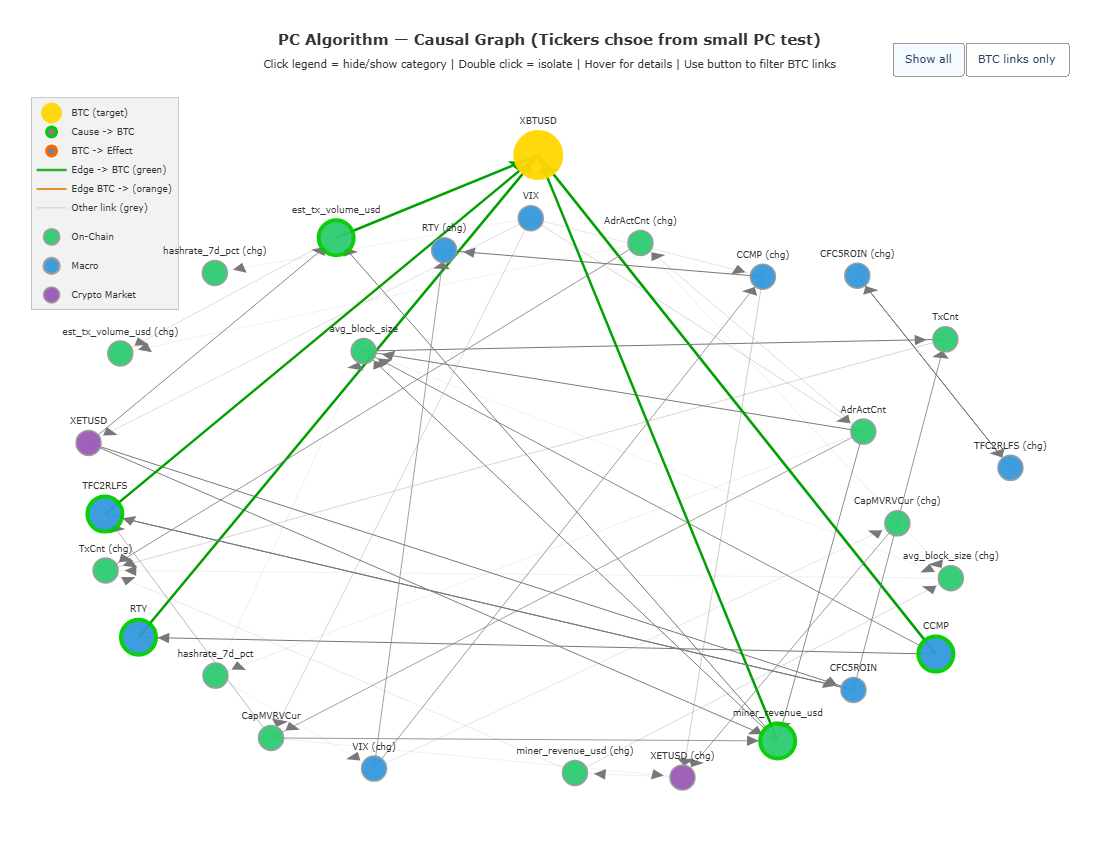

In [94]:
import plotly.graph_objects as go
import networkx as nx
import numpy as np


def plot_dag_arrows(cg_object, nodes, df_returns, causes, effets, bidirect, target_ticker):
    """
    cg_object: le cg.G retourné par causallearn (PAS adj_matrix)
    """

    G = nx.DiGraph()

    # Construire le graphe depuis l'objet causallearn (PAS depuis adj_matrix)
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            node_i = cg_object.nodes[i]
            node_j = cg_object.nodes[j]
            edge = cg_object.get_edge(node_i, node_j)
            if edge is None:
                continue
            ep1 = str(edge.get_endpoint1())  # côté node_i
            ep2 = str(edge.get_endpoint2())  # côté node_j

            if ep1 == "TAIL" and ep2 == "ARROW":
                G.add_edge(nodes[i], nodes[j])  # i → j
            elif ep1 == "ARROW" and ep2 == "TAIL":
                G.add_edge(nodes[j], nodes[i])  # j → i
            elif ep1 == "ARROW" and ep2 == "ARROW":
                G.add_edge(nodes[i], nodes[j])
                G.add_edge(nodes[j], nodes[i])
            else:
                # Non orienté — on met les deux directions
                G.add_edge(nodes[i], nodes[j])
                G.add_edge(nodes[j], nodes[i])

    btc_neighbors = set(G.predecessors(target_ticker)) | set(G.successors(target_ticker))
    btc_neighbors.add(target_ticker)

    pos = nx.spring_layout(G, seed=42, k=2.5)
    pos[target_ticker] = np.array([0.0, 1.2])
    corr_matrix = np.abs(np.corrcoef(df_returns.values.T))

    all_traces = []
    vis_all = []
    vis_btc_only = []

    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        idx_u = nodes.index(u) if u in nodes else -1
        idx_v = nodes.index(v) if v in nodes else -1
        weight = corr_matrix[idx_u, idx_v] if idx_u >= 0 and idx_v >= 0 else 0.3
        alpha = max(0.1, min(1.0, weight * 1.5))
        cat_u, cat_v = get_category(u), get_category(v)
        is_btc_edge = (u == target_ticker or v == target_ticker)

        # u → v : si v est BTC, c'est une cause (vert)
        #         si u est BTC, c'est un effet (orange)
        if v == target_ticker:
            rgba  = f"rgba(0, 160, 0, {alpha})"
            solid = "rgb(0, 160, 0)"
            width = 2.5
        elif u == target_ticker:
            rgba  = f"rgba(220, 120, 0, {alpha})"
            solid = "rgb(220, 120, 0)"
            width = 2.0
        else:
            rgba  = f"rgba(120, 120, 120, {alpha})"
            solid = "rgb(120, 120, 120)"
            width = 1.0

        if cat_u == "BTC (target)":    edge_groups = [cat_v]
        elif cat_v == "BTC (target)":  edge_groups = [cat_u]
        else:                          edge_groups = [cat_u]

        # Triangle de flèche : pointe vers v (la destination)
        dx, dy = x1 - x0, y1 - y0
        length = np.sqrt(dx**2 + dy**2)
        if length > 0:
            ux_n, uy_n = dx / length, dy / length
            tip_x = x1 - ux_n * 0.04
            tip_y = y1 - uy_n * 0.04
            perp_x, perp_y = -uy_n, ux_n
            arrow_size = 0.018
            base1_x = tip_x - ux_n * 0.025 + perp_x * arrow_size
            base1_y = tip_y - uy_n * 0.025 + perp_y * arrow_size
            base2_x = tip_x - ux_n * 0.025 - perp_x * arrow_size
            base2_y = tip_y - uy_n * 0.025 - perp_y * arrow_size
        else:
            tip_x, tip_y = x1, y1
            base1_x, base1_y = x1, y1
            base2_x, base2_y = x1, y1

        for grp in edge_groups:
            # Ligne
            all_traces.append(go.Scatter(
                x=[x0, x1, None], y=[y0, y1, None], mode='lines',
                line=dict(width=width, color=rgba),
                hoverinfo='none', showlegend=False, legendgroup=grp))
            vis_all.append(True)
            vis_btc_only.append(is_btc_edge)

            # Pointe de flèche (triangle)
            all_traces.append(go.Scatter(
                x=[tip_x, base1_x, base2_x, tip_x, None],
                y=[tip_y, base1_y, base2_y, tip_y, None],
                mode='lines', fill='toself',
                fillcolor=solid, line=dict(width=0, color=solid),
                hoverinfo='none', showlegend=False, legendgroup=grp))
            vis_all.append(True)
            vis_btc_only.append(is_btc_edge)

    # --- NODES ---
    for cat, color in CATEGORY_COLORS.items():
        cat_nodes = [n for n in G.nodes() if get_category(n) == cat]
        if not cat_nodes: continue
        cx, cy, csizes, ctext, chover, cborders, cborder_w = [], [], [], [], [], [], []
        for node in cat_nodes:
            x, y = pos[node]
            cx.append(x); cy.append(y)
            in_e = list(G.predecessors(node))
            out_e = list(G.successors(node))
            chover.append(
                f"<b>{node}</b><br>Category: {cat}<br>"
                f"Receives from: {len(in_e)} nodes<br>Sends to: {len(out_e)} nodes<br>"
                f"Connections: {', '.join(in_e + out_e) if in_e + out_e else 'none'}")
            ctext.append(node.replace(" Index","").replace(" Curncy","").replace("_chg"," (chg)"))
            if node == target_ticker:
                csizes.append(45); cborders.append("#FFD700"); cborder_w.append(5)
            elif node in causes:
                csizes.append(35); cborders.append("#00CC00"); cborder_w.append(4)
            elif node in effets:
                csizes.append(35); cborders.append("#FF6600"); cborder_w.append(4)
            elif node in bidirect:
                csizes.append(35); cborders.append("#CC00CC"); cborder_w.append(4)
            else:
                csizes.append(25); cborders.append("#999999"); cborder_w.append(1.5)
        has_btc = any(n in btc_neighbors for n in cat_nodes)
        lg = '_noclick' if cat == "BTC (target)" else cat
        all_traces.append(go.Scatter(
            x=cx, y=cy, mode='markers+text', name=cat,
            text=ctext, textposition='top center',
            textfont=dict(size=9, color='#333333'),
            hovertext=chover, hoverinfo='text',
            marker=dict(size=csizes, color=color,
                        line=dict(color=cborders, width=cborder_w), opacity=0.95),
            legendgroup=lg, showlegend=True))
        vis_all.append(True)
        vis_btc_only.append(True if cat == "BTC (target)" or has_btc else False)

    # --- LEGEND ---
    for t in [
        go.Scatter(x=[None],y=[None],mode='markers',
            marker=dict(size=10,color='gray',line=dict(color='#00CC00',width=3)),
            name='Cause -> BTC',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='markers',
            marker=dict(size=10,color='gray',line=dict(color='#FF6600',width=3)),
            name='BTC -> Effect',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='lines',
            line=dict(color='rgba(0,160,0,0.8)',width=2.5),
            name='Edge -> BTC (green)',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='lines',
            line=dict(color='rgba(220,120,0,0.8)',width=2),
            name='Edge BTC -> (orange)',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='lines',
            line=dict(color='rgba(120,120,120,0.3)',width=1),
            name='Other link (grey)',showlegend=True,legendgroup='_noclick'),
    ]:
        all_traces.append(t); vis_all.append(True); vis_btc_only.append(True)

    fig = go.Figure(data=all_traces, layout=go.Layout(
        title=dict(text=("<b>PC Algorithm — Causal Graph (Tickers chsoe from small PC test)</b><br>"
            "<sub>Click legend = hide/show category | Double click = isolate | "
            "Hover for details | Use button to filter BTC links</sub>"),
            font=dict(size=15, color='#333333'), x=0.5),
        paper_bgcolor='white', plot_bgcolor='white', showlegend=True,
        legend=dict(bgcolor='rgba(0,0,0,0.05)', bordercolor='rgba(0,0,0,0.2)',
            borderwidth=1, font=dict(color='#333333', size=9),
            x=0.01, y=0.99, groupclick='togglegroup'),
        hovermode='closest',
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        margin=dict(l=20, r=20, t=90, b=20), height=850,
        updatemenus=[dict(type="buttons", direction="left",
            x=0.99, y=1.02, xanchor="right", yanchor="bottom",
            buttons=[
                dict(label="Show all", method="update",
                     args=[{"visible": vis_all}]),
                dict(label="BTC links only", method="update",
                     args=[{"visible": vis_btc_only}]),
            ], bgcolor="white", bordercolor="#999", font=dict(size=11))],
    ))
    import webbrowser, os
    filepath = os.path.abspath("causal_graph_arrows.html")
    fig.write_html(filepath, include_plotlyjs=True)
    fig.show()
    webbrowser.open("file://" + filepath)

# APPEL — on passe cg.G (pas cg.G.graph)
plot_dag_arrows(cg.G, node_names, df_returns, causes, effets, bidirect, target_ticker)

**Random Forest — Test 1 (RF-selected features)**


In [95]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier

START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"
HORIZONS = [1, 7, 14, 30, 60]
N_BINS = 3
MIN_NON_NA_FRAC = 0.70
MIN_ROWS = 300

RF_PARAMS = dict(
    n_estimators=400, max_depth=12, min_samples_split=10,
    min_samples_leaf=5, max_features="sqrt",
    class_weight="balanced", random_state=42, n_jobs=-1)

CAUSAL_VARS = causes.copy()
CAUSAL_VARS_EXTENDED = []
for v in CAUSAL_VARS:
    CAUSAL_VARS_EXTENDED.append(v)
    if v + "_chg" in df_returns.columns:
        CAUSAL_VARS_EXTENDED.append(v + "_chg")
CAUSAL_VARS_EXTENDED = list(set(CAUSAL_VARS_EXTENDED))
print(f"Causal vars (PC): {CAUSAL_VARS}")
print(f"Causal vars extended: {CAUSAL_VARS_EXTENDED}")

def calculate_returns(prices, horizon):
    return (prices.shift(-horizon) - prices) / prices

def fit_bins(train_ret, n=3):
    qs = np.quantile(train_ret.dropna().values, np.linspace(0, 1, n+1))
    qs[0], qs[-1] = -np.inf, np.inf
    for i in range(1, len(qs)):
        if qs[i] <= qs[i-1]: qs[i] = qs[i-1] + 1e-12
    return qs

def run_rf(pivot_df, feature_cols, horizon, label=""):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(START_DATE)]
    btc_col = "XBTUSD Curncy"
    if btc_col not in df.columns: return None
    ret = calculate_returns(df[btc_col].astype(float), horizon)
    feats = [c for c in feature_cols if c in df.columns and c != btc_col]
    if len(feats) < 3: return None
    df_m = df[feats].ffill().copy()
    thresh = int(MIN_NON_NA_FRAC * len(df_m))
    df_m = df_m.dropna(axis=1, thresh=thresh)
    feats = list(df_m.columns)
    df_m["target"] = ret
    df_m = df_m.dropna(subset=["target"])
    cut = pd.to_datetime(TRAIN_END_DATE)
    tr = df_m[df_m.index <= cut]
    te = df_m[df_m.index > cut]
    if len(tr) < MIN_ROWS or len(te) < 50: return None
    bins = fit_bins(tr["target"], N_BINS)
    y_tr = pd.cut(tr["target"], bins=bins, labels=False).dropna().astype(int)
    y_te = pd.cut(te["target"], bins=bins, labels=False).dropna().astype(int)
    X_tr = tr[feats].loc[y_tr.index]
    X_te = te[feats].loc[y_te.index]
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    clf = RandomForestClassifier(**RF_PARAMS)
    clf.fit(X_tr_s, y_tr)
    y_pred = clf.predict(X_te_s)
    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_tr_s, y_tr)
    y_dum = dummy.predict(X_te_s)
    imp = pd.DataFrame({"feature": feats, "importance": clf.feature_importances_})
    imp = imp.sort_values("importance", ascending=False).reset_index(drop=True)
    imp["rank"] = np.arange(1, len(imp)+1)
    return {
        "label": label, "horizon": horizon, "n_features": len(feats),
        "n_train": len(y_tr), "n_test": len(y_te),
        "acc": accuracy_score(y_te, y_pred),
        "bal_acc": balanced_accuracy_score(y_te, y_pred),
        "macro_f1": f1_score(y_te, y_pred, average="macro"),
        "cm": confusion_matrix(y_te, y_pred, labels=list(range(N_BINS))),
        "dummy_acc": accuracy_score(y_te, y_dum),
        "dummy_bal_acc": balanced_accuracy_score(y_te, y_dum),
        "imp_full": imp, "features_used": feats,
    }

all_features = [c for c in pivot_df.columns if c != "XBTUSD Curncy"]
results_all_1 = []
results_causal_1 = []

for h in HORIZONS:
    print(f"\n{{'='*70}}")
    print(f"HORIZON = {{h}} days")
    print(f"{{'='*70}}")

    ra = run_rf(pivot_df, all_features, h, "All variables")
    if ra:
        results_all_1.append(ra)
        print(f"  ALL VARS     -> Acc={{ra['acc']*100:.1f}}% | BalAcc={{ra['bal_acc']*100:.1f}}% | F1={{ra['macro_f1']:.3f}} | {{ra['n_features']}} feats")

    rc = run_rf(pivot_df, CAUSAL_VARS_EXTENDED, h, "Causal only")
    if rc:
        results_causal_1.append(rc)
        print(f"  CAUSAL ONLY  -> Acc={{rc['acc']*100:.1f}}% | BalAcc={{rc['bal_acc']*100:.1f}}% | F1={{rc['macro_f1']:.3f}} | {{rc['n_features']}} feats")

    if ra and rc:
        d = (rc['acc'] - ra['acc']) * 100
        print(f"  DELTA        -> Acc: {{d:+.1f}}pp | F1: {{rc['macro_f1']-ra['macro_f1']:+.3f}}")


# Summary
all_res = results_all_1 + results_causal_1
if all_res:
    s = pd.DataFrame([{
        "Model": r["label"], "Horizon": r["horizon"],
        "Features": r["n_features"],
        "Acc (%)": round(r["acc"]*100,1),
        "BalAcc (%)": round(r["bal_acc"]*100,1),
        "F1": round(r["macro_f1"],3),
        "Dummy Acc (%)": round(r["dummy_acc"]*100,1),
    } for r in all_res]).sort_values(["Horizon","Model"])
    print(f"\n{'='*70}")
    print("COMPARISON: ALL VARIABLES vs CAUSAL ONLY")
    print(f"{'='*70}")
    print(s.to_string(index=False))


Causal vars (PC): ['CCMP Index', 'RTY Index', 'TFC2RLFS Index', 'miner_revenue_usd', 'est_tx_volume_usd']
Causal vars extended: ['est_tx_volume_usd', 'RTY Index', 'CCMP Index_chg', 'miner_revenue_usd', 'est_tx_volume_usd_chg', 'RTY Index_chg', 'TFC2RLFS Index_chg', 'TFC2RLFS Index', 'CCMP Index', 'miner_revenue_usd_chg']

{'='*70}
HORIZON = {h} days
{'='*70}
  ALL VARS     -> Acc={ra['acc']*100:.1f}% | BalAcc={ra['bal_acc']*100:.1f}% | F1={ra['macro_f1']:.3f} | {ra['n_features']} feats
  CAUSAL ONLY  -> Acc={rc['acc']*100:.1f}% | BalAcc={rc['bal_acc']*100:.1f}% | F1={rc['macro_f1']:.3f} | {rc['n_features']} feats
  DELTA        -> Acc: {d:+.1f}pp | F1: {rc['macro_f1']-ra['macro_f1']:+.3f}

{'='*70}
HORIZON = {h} days
{'='*70}
  ALL VARS     -> Acc={ra['acc']*100:.1f}% | BalAcc={ra['bal_acc']*100:.1f}% | F1={ra['macro_f1']:.3f} | {ra['n_features']} feats
  CAUSAL ONLY  -> Acc={rc['acc']*100:.1f}% | BalAcc={rc['bal_acc']*100:.1f}% | F1={rc['macro_f1']:.3f} | {rc['n_features']} feats
  DE

### Tickers chose from ML test

In [96]:
selected_tickers = ['BDIY Index', 'CESIJPY Index', 'CNH Curncy', 'CapMVRVCur', 'GETB1 Index',
                       'IUTPELC Index', 'JPYUSD Curncy', 'LUATTRUU Index', 
                       'MARA US Equity', 'NVT_Signal', 'RIOT US Equity', 'SplyCur', 'XBNUSD Curncy', 'XETUSD Curncy', 
                       'XLCUSD Curncy', 'XRPUSD Curncy', 'days_since_halving', 'days_to_next_halving']

In [97]:
import pandas as pd
import numpy as np
from causallearn.search.ConstraintBased.PC import pc

target_ticker = "XBTUSD Curncy"

# --- Categories for Plotly graph ---
CATEGORY_MAP = {
    'HashRate': 'On-Chain', 'mining_difficulty': 'On-Chain',
    'miner_revenue_usd': 'On-Chain', 'hashrate_7d_pct': 'On-Chain',
    'AdrActCnt': 'On-Chain', 'TxCnt': 'On-Chain', 'TxTfrCnt': 'On-Chain',
    'est_tx_volume_usd': 'On-Chain', 'avg_block_size': 'On-Chain',
    'tx_fees_usd': 'On-Chain', 'CapMVRVCur': 'On-Chain', 'NVT': 'On-Chain',
    'NVT_Signal': 'On-Chain', 'SplyCur': 'On-Chain',
    'VIX Index': 'Macro', 'MOVE Index': 'Macro', 'DXY Curncy': 'Macro',
    'XAU Curncy': 'Macro', 'SPX Index': 'Macro', 'CCMP Index': 'Macro',
    'RTY Index': 'Macro', 'USYC2Y10 Index': 'Macro', 'DEYC2Y10 Index': 'Macro',
    'M2 Index': 'Macro', 'FARBAST Index': 'Macro',
    'TFC2RLFS Index': 'Macro', 'CFC5ROIN Index': 'Macro',
    'fear_and_greed': 'Sentiment', 'total_stablecoin_mcap': 'Sentiment',
    'btc_balance_on_exchanges': 'Sentiment', 'btc_dominance_proxy': 'Sentiment',
    'Bitcoin': 'Sentiment', 'Coinbase': 'Sentiment',
    'BlackRock Bitcoin': 'Sentiment', 'Buy Bitcoin': 'Sentiment',
    'XETUSD Curncy': 'Crypto Market', 'XBNUSD Curncy': 'Crypto Market',
    'XRPUSD Curncy': 'Crypto Market',
    'BDIY Index': 'Macro', 'CESIJPY Index': 'Macro', 'CNH Curncy': 'Macro',
    'GETB1 Index': 'Macro', 'IUTPELC Index': 'Macro', 'JPYUSD Curncy': 'Macro',
    'LUATTRUU Index': 'Macro',
    'MARA US Equity': 'On-Chain', 'RIOT US Equity': 'On-Chain',
    'XLCUSD Curncy': 'Crypto Market',
    'days_since_halving': 'On-Chain', 'days_to_next_halving': 'On-Chain',
    'XBTUSD Curncy': 'BTC (target)',
}
CATEGORY_COLORS = {
    'BTC (target)': '#FFD700', 'On-Chain': '#2ecc71',
    'Macro': '#3498db', 'Sentiment': '#e74c3c', 'Crypto Market': '#9b59b6',
}
def get_category(ticker):
    return CATEGORY_MAP.get(ticker, 'Other')

for key in list(CATEGORY_MAP.keys()):
    CATEGORY_MAP[key + "_chg"] = CATEGORY_MAP[key]

BOUNDED_FEATURES = {
    'fear_and_greed', 'CapMVRVCur', 'NVT', 'NVT_Signal',
    'VIX Index', 'MOVE Index', 'USYC2Y10 Index', 'DEYC2Y10 Index'
}
GOOGLE_TRENDS = {'Bitcoin', 'Coinbase', 'BlackRock Bitcoin', 'Buy Bitcoin'}

# ============================================================
# 1. SELECTION + FILTER
# ============================================================
available_cols = [col for col in selected_tickers if col in pivot_df.columns]
if target_ticker in pivot_df.columns and target_ticker not in available_cols:
    available_cols.append(target_ticker)
available_cols = list(dict.fromkeys(available_cols))

df_sub = pivot_df[available_cols].copy()
df_sub = df_sub[df_sub.index >= "2010-01-01"]
df_sub = df_sub.resample('D').mean()
df_sub = df_sub.dropna(thresh=30, axis=1)

cols = pd.Series(df_sub.columns)
for dup in cols[cols.duplicated()].unique():
    dup_idx = cols[cols == dup].index.tolist()
    for suffix_i, idx in enumerate(dup_idx):
        cols[idx] = f"{dup}_{suffix_i}" if suffix_i > 0 else dup
df_sub.columns = cols

print(f"Columns ({len(df_sub.columns)}): {list(df_sub.columns)}")
print(f"Period: {df_sub.index.min()} -> {df_sub.index.max()}")
print(f"Shape: {df_sub.shape}")

# ============================================================
# 2. FEATURES: LEVELS + CHANGES
# ============================================================
df_levels = df_sub.ffill().copy()

df_changes = pd.DataFrame(index=df_sub.index)
for col in df_sub.columns:
    if col == target_ticker:
        continue  # NO _chg for BTC itself
    if col in BOUNDED_FEATURES or col in GOOGLE_TRENDS:
        df_changes[col + "_chg"] = df_sub[col].diff()
    else:
        df_changes[col + "_chg"] = df_sub[col].pct_change()

df_returns = pd.concat([df_levels, df_changes], axis=1)
df_returns = df_returns.iloc[1:]
df_returns = df_returns.replace([np.inf, -np.inf], np.nan)
df_returns = df_returns.ffill()
df_returns = df_returns.fillna(df_returns.mean())
df_returns = df_returns.dropna(axis=1)

print(f"\nShape with levels + changes: {df_returns.shape}")
print(f"Level columns: {[c for c in df_returns.columns if '_chg' not in c]}")
print(f"Change columns: {[c for c in df_returns.columns if '_chg' in c]}")

# ============================================================
# 3. PC ALGORITHM
# ============================================================
if target_ticker not in df_returns.columns:
    print(f"ERROR: {target_ticker} not in columns!")
else:
    node_names = list(df_returns.columns)
    btc_idx = node_names.index(target_ticker)

    cg = pc(
        df_returns.values,
        alpha=0.05,
        indep_test='fisherz',
        node_names=node_names
    )

    # ============================================================
    # 4. CAUSAL LINKS ANALYSIS
    # ============================================================
    causes = []
    effets = []
    bidirect = []
    nonorient = []

    for i in range(len(node_names)):
        if i == btc_idx:
            continue
        node_i   = cg.G.nodes[i]
        node_btc = cg.G.nodes[btc_idx]
        edge     = cg.G.get_edge(node_i, node_btc)
        if edge is None:
            continue
        ep1 = str(edge.get_endpoint1())
        ep2 = str(edge.get_endpoint2())
        if ep1 == "TAIL" and ep2 == "ARROW":
            causes.append(node_names[i])
        elif ep1 == "ARROW" and ep2 == "TAIL":
            effets.append(node_names[i])
        elif ep1 == "ARROW" and ep2 == "ARROW":
            bidirect.append(node_names[i])
        else:
            nonorient.append(node_names[i])

    print(f"\n{'='*60}")
    print(f"CAUSAL LINKS WITH {target_ticker}")
    print(f"{'='*60}")
    print(f"\nCAUSES ({len(causes)}):")
    for c in causes: print(f"   {c}  -->  BTC")
    print(f"\nEFFECTS ({len(effets)}):")
    for e in effets: print(f"   BTC  -->  {e}")
    print(f"\nBIDIRECTIONAL ({len(bidirect)}):")
    for b in bidirect: print(f"   {b}  <-->  BTC")
    print(f"\nUNORIENTED ({len(nonorient)}):")
    for n in nonorient: print(f"   {n}  --  BTC")
    print(f"\nTOTAL: {len(causes)} cause(s), {len(effets)} effect(s), "
          f"{len(bidirect)} bidirectional, {len(nonorient)} unoriented")

Columns (19): ['BDIY Index', 'CESIJPY Index', 'CNH Curncy', 'CapMVRVCur', 'GETB1 Index', 'IUTPELC Index', 'JPYUSD Curncy', 'LUATTRUU Index', 'MARA US Equity', 'NVT_Signal', 'RIOT US Equity', 'SplyCur', 'XBNUSD Curncy', 'XETUSD Curncy', 'XLCUSD Curncy', 'XRPUSD Curncy', 'days_since_halving', 'days_to_next_halving', 'XBTUSD Curncy']
Period: 2010-01-01 00:00:00 -> 2025-11-04 00:00:00
Shape: (5787, 19)

Shape with levels + changes: (5786, 37)
Level columns: ['BDIY Index', 'CESIJPY Index', 'CNH Curncy', 'CapMVRVCur', 'GETB1 Index', 'IUTPELC Index', 'JPYUSD Curncy', 'LUATTRUU Index', 'MARA US Equity', 'NVT_Signal', 'RIOT US Equity', 'SplyCur', 'XBNUSD Curncy', 'XETUSD Curncy', 'XLCUSD Curncy', 'XRPUSD Curncy', 'days_since_halving', 'days_to_next_halving', 'XBTUSD Curncy']
Change columns: ['BDIY Index_chg', 'CESIJPY Index_chg', 'CNH Curncy_chg', 'CapMVRVCur_chg', 'GETB1 Index_chg', 'IUTPELC Index_chg', 'JPYUSD Curncy_chg', 'LUATTRUU Index_chg', 'MARA US Equity_chg', 'NVT_Signal_chg', 'RIOT US

C:\Users\marce\AppData\Local\Temp\ipykernel_5476\2313887545.py:86: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\marce\AppData\Local\Temp\ipykernel_5476\2313887545.py:86: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\marce\AppData\Local\Temp\ipykernel_5476\2313887545.py:86: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\marce\AppData\Local\Temp\ipykernel_5476\2313887545.py:8

  0%|          | 0/37 [00:00<?, ?it/s]


CAUSAL LINKS WITH XBTUSD Curncy

CAUSES (4):
   LUATTRUU Index  -->  BTC
   SplyCur  -->  BTC
   XETUSD Curncy  -->  BTC
   XRPUSD Curncy  -->  BTC

EFFECTS (0):

BIDIRECTIONAL (0):

UNORIENTED (0):

TOTAL: 4 cause(s), 0 effect(s), 0 bidirectional, 0 unoriented


In [98]:
import plotly.graph_objects as go
import networkx as nx
import numpy as np


def plot_dag_arrows(cg_object, nodes, df_returns, causes, effets, bidirect, target_ticker):
    """
    cg_object: le cg.G retourné par causallearn (PAS adj_matrix)
    """

    G = nx.DiGraph()

    # Construire le graphe depuis l'objet causallearn (PAS depuis adj_matrix)
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            node_i = cg_object.nodes[i]
            node_j = cg_object.nodes[j]
            edge = cg_object.get_edge(node_i, node_j)
            if edge is None:
                continue
            ep1 = str(edge.get_endpoint1())  # côté node_i
            ep2 = str(edge.get_endpoint2())  # côté node_j

            if ep1 == "TAIL" and ep2 == "ARROW":
                G.add_edge(nodes[i], nodes[j])  # i → j
            elif ep1 == "ARROW" and ep2 == "TAIL":
                G.add_edge(nodes[j], nodes[i])  # j → i
            elif ep1 == "ARROW" and ep2 == "ARROW":
                G.add_edge(nodes[i], nodes[j])
                G.add_edge(nodes[j], nodes[i])
            else:
                # Non orienté — on met les deux directions
                G.add_edge(nodes[i], nodes[j])
                G.add_edge(nodes[j], nodes[i])

    btc_neighbors = set(G.predecessors(target_ticker)) | set(G.successors(target_ticker))
    btc_neighbors.add(target_ticker)

    pos = nx.spring_layout(G, seed=42, k=2.5)
    pos[target_ticker] = np.array([0.0, 1.2])
    corr_matrix = np.abs(np.corrcoef(df_returns.values.T))

    all_traces = []
    vis_all = []
    vis_btc_only = []

    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        idx_u = nodes.index(u) if u in nodes else -1
        idx_v = nodes.index(v) if v in nodes else -1
        weight = corr_matrix[idx_u, idx_v] if idx_u >= 0 and idx_v >= 0 else 0.3
        alpha = max(0.1, min(1.0, weight * 1.5))
        cat_u, cat_v = get_category(u), get_category(v)
        is_btc_edge = (u == target_ticker or v == target_ticker)

        # u → v : si v est BTC, c'est une cause (vert)
        #         si u est BTC, c'est un effet (orange)
        if v == target_ticker:
            rgba  = f"rgba(0, 160, 0, {alpha})"
            solid = "rgb(0, 160, 0)"
            width = 2.5
        elif u == target_ticker:
            rgba  = f"rgba(220, 120, 0, {alpha})"
            solid = "rgb(220, 120, 0)"
            width = 2.0
        else:
            rgba  = f"rgba(120, 120, 120, {alpha})"
            solid = "rgb(120, 120, 120)"
            width = 1.0

        if cat_u == "BTC (target)":    edge_groups = [cat_v]
        elif cat_v == "BTC (target)":  edge_groups = [cat_u]
        else:                          edge_groups = [cat_u]

        # Triangle de flèche : pointe vers v (la destination)
        dx, dy = x1 - x0, y1 - y0
        length = np.sqrt(dx**2 + dy**2)
        if length > 0:
            ux_n, uy_n = dx / length, dy / length
            tip_x = x1 - ux_n * 0.04
            tip_y = y1 - uy_n * 0.04
            perp_x, perp_y = -uy_n, ux_n
            arrow_size = 0.018
            base1_x = tip_x - ux_n * 0.025 + perp_x * arrow_size
            base1_y = tip_y - uy_n * 0.025 + perp_y * arrow_size
            base2_x = tip_x - ux_n * 0.025 - perp_x * arrow_size
            base2_y = tip_y - uy_n * 0.025 - perp_y * arrow_size
        else:
            tip_x, tip_y = x1, y1
            base1_x, base1_y = x1, y1
            base2_x, base2_y = x1, y1

        for grp in edge_groups:
            # Ligne
            all_traces.append(go.Scatter(
                x=[x0, x1, None], y=[y0, y1, None], mode='lines',
                line=dict(width=width, color=rgba),
                hoverinfo='none', showlegend=False, legendgroup=grp))
            vis_all.append(True)
            vis_btc_only.append(is_btc_edge)

            # Pointe de flèche (triangle)
            all_traces.append(go.Scatter(
                x=[tip_x, base1_x, base2_x, tip_x, None],
                y=[tip_y, base1_y, base2_y, tip_y, None],
                mode='lines', fill='toself',
                fillcolor=solid, line=dict(width=0, color=solid),
                hoverinfo='none', showlegend=False, legendgroup=grp))
            vis_all.append(True)
            vis_btc_only.append(is_btc_edge)

    # --- NODES ---
    for cat, color in CATEGORY_COLORS.items():
        cat_nodes = [n for n in G.nodes() if get_category(n) == cat]
        if not cat_nodes: continue
        cx, cy, csizes, ctext, chover, cborders, cborder_w = [], [], [], [], [], [], []
        for node in cat_nodes:
            x, y = pos[node]
            cx.append(x); cy.append(y)
            in_e = list(G.predecessors(node))
            out_e = list(G.successors(node))
            chover.append(
                f"<b>{node}</b><br>Category: {cat}<br>"
                f"Receives from: {len(in_e)} nodes<br>Sends to: {len(out_e)} nodes<br>"
                f"Connections: {', '.join(in_e + out_e) if in_e + out_e else 'none'}")
            ctext.append(node.replace(" Index","").replace(" Curncy","").replace("_chg"," (chg)"))
            if node == target_ticker:
                csizes.append(45); cborders.append("#FFD700"); cborder_w.append(5)
            elif node in causes:
                csizes.append(35); cborders.append("#00CC00"); cborder_w.append(4)
            elif node in effets:
                csizes.append(35); cborders.append("#FF6600"); cborder_w.append(4)
            elif node in bidirect:
                csizes.append(35); cborders.append("#CC00CC"); cborder_w.append(4)
            else:
                csizes.append(25); cborders.append("#999999"); cborder_w.append(1.5)
        has_btc = any(n in btc_neighbors for n in cat_nodes)
        lg = '_noclick' if cat == "BTC (target)" else cat
        all_traces.append(go.Scatter(
            x=cx, y=cy, mode='markers+text', name=cat,
            text=ctext, textposition='top center',
            textfont=dict(size=9, color='#333333'),
            hovertext=chover, hoverinfo='text',
            marker=dict(size=csizes, color=color,
                        line=dict(color=cborders, width=cborder_w), opacity=0.95),
            legendgroup=lg, showlegend=True))
        vis_all.append(True)
        vis_btc_only.append(True if cat == "BTC (target)" or has_btc else False)

    # --- LEGEND ---
    for t in [
        go.Scatter(x=[None],y=[None],mode='markers',
            marker=dict(size=10,color='gray',line=dict(color='#00CC00',width=3)),
            name='Cause -> BTC',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='markers',
            marker=dict(size=10,color='gray',line=dict(color='#FF6600',width=3)),
            name='BTC -> Effect',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='lines',
            line=dict(color='rgba(0,160,0,0.8)',width=2.5),
            name='Edge -> BTC (green)',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='lines',
            line=dict(color='rgba(220,120,0,0.8)',width=2),
            name='Edge BTC -> (orange)',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='lines',
            line=dict(color='rgba(120,120,120,0.3)',width=1),
            name='Other link (grey)',showlegend=True,legendgroup='_noclick'),
    ]:
        all_traces.append(t); vis_all.append(True); vis_btc_only.append(True)

    fig = go.Figure(data=all_traces, layout=go.Layout(
        title=dict(text=("<b>PC Algorithm — Causal Graph (Tickers chose from ML test)</b><br>"
            "<sub>Click legend = hide/show category | Double click = isolate | "
            "Hover for details | Use button to filter BTC links</sub>"),
            font=dict(size=15, color='#333333'), x=0.5),
        paper_bgcolor='white', plot_bgcolor='white', showlegend=True,
        legend=dict(bgcolor='rgba(0,0,0,0.05)', bordercolor='rgba(0,0,0,0.2)',
            borderwidth=1, font=dict(color='#333333', size=9),
            x=0.01, y=0.99, groupclick='togglegroup'),
        hovermode='closest',
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        margin=dict(l=20, r=20, t=90, b=20), height=850,
        updatemenus=[dict(type="buttons", direction="left",
            x=0.99, y=1.02, xanchor="right", yanchor="bottom",
            buttons=[
                dict(label="Show all", method="update",
                     args=[{"visible": vis_all}]),
                dict(label="BTC links only", method="update",
                     args=[{"visible": vis_btc_only}]),
            ], bgcolor="white", bordercolor="#999", font=dict(size=11))],
    ))
    import webbrowser, os
    filepath = os.path.abspath("causal_graph_arrows.html")
    fig.write_html(filepath, include_plotlyjs=True)
    fig.show()
    webbrowser.open("file://" + filepath)

# APPEL — on passe cg.G (pas cg.G.graph)
plot_dag_arrows(cg.G, node_names, df_returns, causes, effets, bidirect, target_ticker)

**Random Forest — Test 2 (ML-selected features)**


In [99]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier

START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"
HORIZONS = [1, 7, 14, 30, 60]
N_BINS = 3
MIN_NON_NA_FRAC = 0.70
MIN_ROWS = 300

RF_PARAMS = dict(
    n_estimators=400, max_depth=12, min_samples_split=10,
    min_samples_leaf=5, max_features="sqrt",
    class_weight="balanced", random_state=42, n_jobs=-1)

CAUSAL_VARS = causes.copy()
CAUSAL_VARS_EXTENDED = []
for v in CAUSAL_VARS:
    CAUSAL_VARS_EXTENDED.append(v)
    if v + "_chg" in df_returns.columns:
        CAUSAL_VARS_EXTENDED.append(v + "_chg")
CAUSAL_VARS_EXTENDED = list(set(CAUSAL_VARS_EXTENDED))
print(f"Causal vars (PC): {CAUSAL_VARS}")
print(f"Causal vars extended: {CAUSAL_VARS_EXTENDED}")

def calculate_returns(prices, horizon):
    return (prices.shift(-horizon) - prices) / prices

def fit_bins(train_ret, n=3):
    qs = np.quantile(train_ret.dropna().values, np.linspace(0, 1, n+1))
    qs[0], qs[-1] = -np.inf, np.inf
    for i in range(1, len(qs)):
        if qs[i] <= qs[i-1]: qs[i] = qs[i-1] + 1e-12
    return qs

def run_rf(pivot_df, feature_cols, horizon, label=""):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(START_DATE)]
    btc_col = "XBTUSD Curncy"
    if btc_col not in df.columns: return None
    ret = calculate_returns(df[btc_col].astype(float), horizon)
    feats = [c for c in feature_cols if c in df.columns and c != btc_col]
    if len(feats) < 3: return None
    df_m = df[feats].ffill().copy()
    thresh = int(MIN_NON_NA_FRAC * len(df_m))
    df_m = df_m.dropna(axis=1, thresh=thresh)
    feats = list(df_m.columns)
    df_m["target"] = ret
    df_m = df_m.dropna(subset=["target"])
    cut = pd.to_datetime(TRAIN_END_DATE)
    tr = df_m[df_m.index <= cut]
    te = df_m[df_m.index > cut]
    if len(tr) < MIN_ROWS or len(te) < 50: return None
    bins = fit_bins(tr["target"], N_BINS)
    y_tr = pd.cut(tr["target"], bins=bins, labels=False).dropna().astype(int)
    y_te = pd.cut(te["target"], bins=bins, labels=False).dropna().astype(int)
    X_tr = tr[feats].loc[y_tr.index]
    X_te = te[feats].loc[y_te.index]
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    clf = RandomForestClassifier(**RF_PARAMS)
    clf.fit(X_tr_s, y_tr)
    y_pred = clf.predict(X_te_s)
    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_tr_s, y_tr)
    y_dum = dummy.predict(X_te_s)
    imp = pd.DataFrame({"feature": feats, "importance": clf.feature_importances_})
    imp = imp.sort_values("importance", ascending=False).reset_index(drop=True)
    imp["rank"] = np.arange(1, len(imp)+1)
    return {
        "label": label, "horizon": horizon, "n_features": len(feats),
        "n_train": len(y_tr), "n_test": len(y_te),
        "acc": accuracy_score(y_te, y_pred),
        "bal_acc": balanced_accuracy_score(y_te, y_pred),
        "macro_f1": f1_score(y_te, y_pred, average="macro"),
        "cm": confusion_matrix(y_te, y_pred, labels=list(range(N_BINS))),
        "dummy_acc": accuracy_score(y_te, y_dum),
        "dummy_bal_acc": balanced_accuracy_score(y_te, y_dum),
        "imp_full": imp, "features_used": feats,
    }

all_features = [c for c in pivot_df.columns if c != "XBTUSD Curncy"]
results_all_2 = []
results_causal_2 = []

for h in HORIZONS:
    print(f"\n{{'='*70}}")
    print(f"HORIZON = {{h}} days")
    print(f"{{'='*70}}")

    ra = run_rf(pivot_df, all_features, h, "All variables")
    if ra:
        results_all_2.append(ra)
        print(f"  ALL VARS     -> Acc={{ra['acc']*100:.1f}}% | BalAcc={{ra['bal_acc']*100:.1f}}% | F1={{ra['macro_f1']:.3f}} | {{ra['n_features']}} feats")

    rc = run_rf(pivot_df, CAUSAL_VARS_EXTENDED, h, "Causal only")
    if rc:
        results_causal_2.append(rc)
        print(f"  CAUSAL ONLY  -> Acc={{rc['acc']*100:.1f}}% | BalAcc={{rc['bal_acc']*100:.1f}}% | F1={{rc['macro_f1']:.3f}} | {{rc['n_features']}} feats")

    if ra and rc:
        d = (rc['acc'] - ra['acc']) * 100
        print(f"  DELTA        -> Acc: {{d:+.1f}}pp | F1: {{rc['macro_f1']-ra['macro_f1']:+.3f}}")

all_res = results_all_2 + results_causal_2
if all_res:
    s = pd.DataFrame([{
        "Model": r["label"], "Horizon": r["horizon"],
        "Features": r["n_features"],
        "Acc (%)": round(r["acc"]*100,1),
        "BalAcc (%)": round(r["bal_acc"]*100,1),
        "F1": round(r["macro_f1"],3),
        "Dummy Acc (%)": round(r["dummy_acc"]*100,1),
    } for r in all_res]).sort_values(["Horizon","Model"])
    print(f"\n{'='*70}")
    print("COMPARISON: ALL VARIABLES vs CAUSAL ONLY")
    print(f"{'='*70}")
    print(s.to_string(index=False))


Causal vars (PC): ['LUATTRUU Index', 'SplyCur', 'XETUSD Curncy', 'XRPUSD Curncy']
Causal vars extended: ['XETUSD Curncy', 'SplyCur', 'LUATTRUU Index', 'LUATTRUU Index_chg', 'XETUSD Curncy_chg', 'SplyCur_chg', 'XRPUSD Curncy_chg', 'XRPUSD Curncy']

{'='*70}
HORIZON = {h} days
{'='*70}
  ALL VARS     -> Acc={ra['acc']*100:.1f}% | BalAcc={ra['bal_acc']*100:.1f}% | F1={ra['macro_f1']:.3f} | {ra['n_features']} feats
  CAUSAL ONLY  -> Acc={rc['acc']*100:.1f}% | BalAcc={rc['bal_acc']*100:.1f}% | F1={rc['macro_f1']:.3f} | {rc['n_features']} feats
  DELTA        -> Acc: {d:+.1f}pp | F1: {rc['macro_f1']-ra['macro_f1']:+.3f}

{'='*70}
HORIZON = {h} days
{'='*70}
  ALL VARS     -> Acc={ra['acc']*100:.1f}% | BalAcc={ra['bal_acc']*100:.1f}% | F1={ra['macro_f1']:.3f} | {ra['n_features']} feats
  CAUSAL ONLY  -> Acc={rc['acc']*100:.1f}% | BalAcc={rc['bal_acc']*100:.1f}% | F1={rc['macro_f1']:.3f} | {rc['n_features']} feats
  DELTA        -> Acc: {d:+.1f}pp | F1: {rc['macro_f1']-ra['macro_f1']:+.3f}

{'

## López de Prado's 3-step scientific method for causal factor investing: phenomenology, theory, falsification.
### Combined with Vaissié's 3-pillar data categorization: On-Chain, Sentiment, Macro-economic

**Feature selection justification (Alvaro):** 

We selected a set of 33 features from the initial dataset for the causal pipeline. Each feature was chosen based at least on one of the following sources:

- The table of the most frequent features found in the horizon analysis at each time range (1, 7 or 30 days) that can be found below.
- intersection of Vaissié's specific factor recommendations in _"Bitcoin, un actif comme les autres"_ and López de Prado's methodology in _"Causal Factor Investing"_, explained in detail in this Markdown [file](../resources/feature_selection_justification.md) 

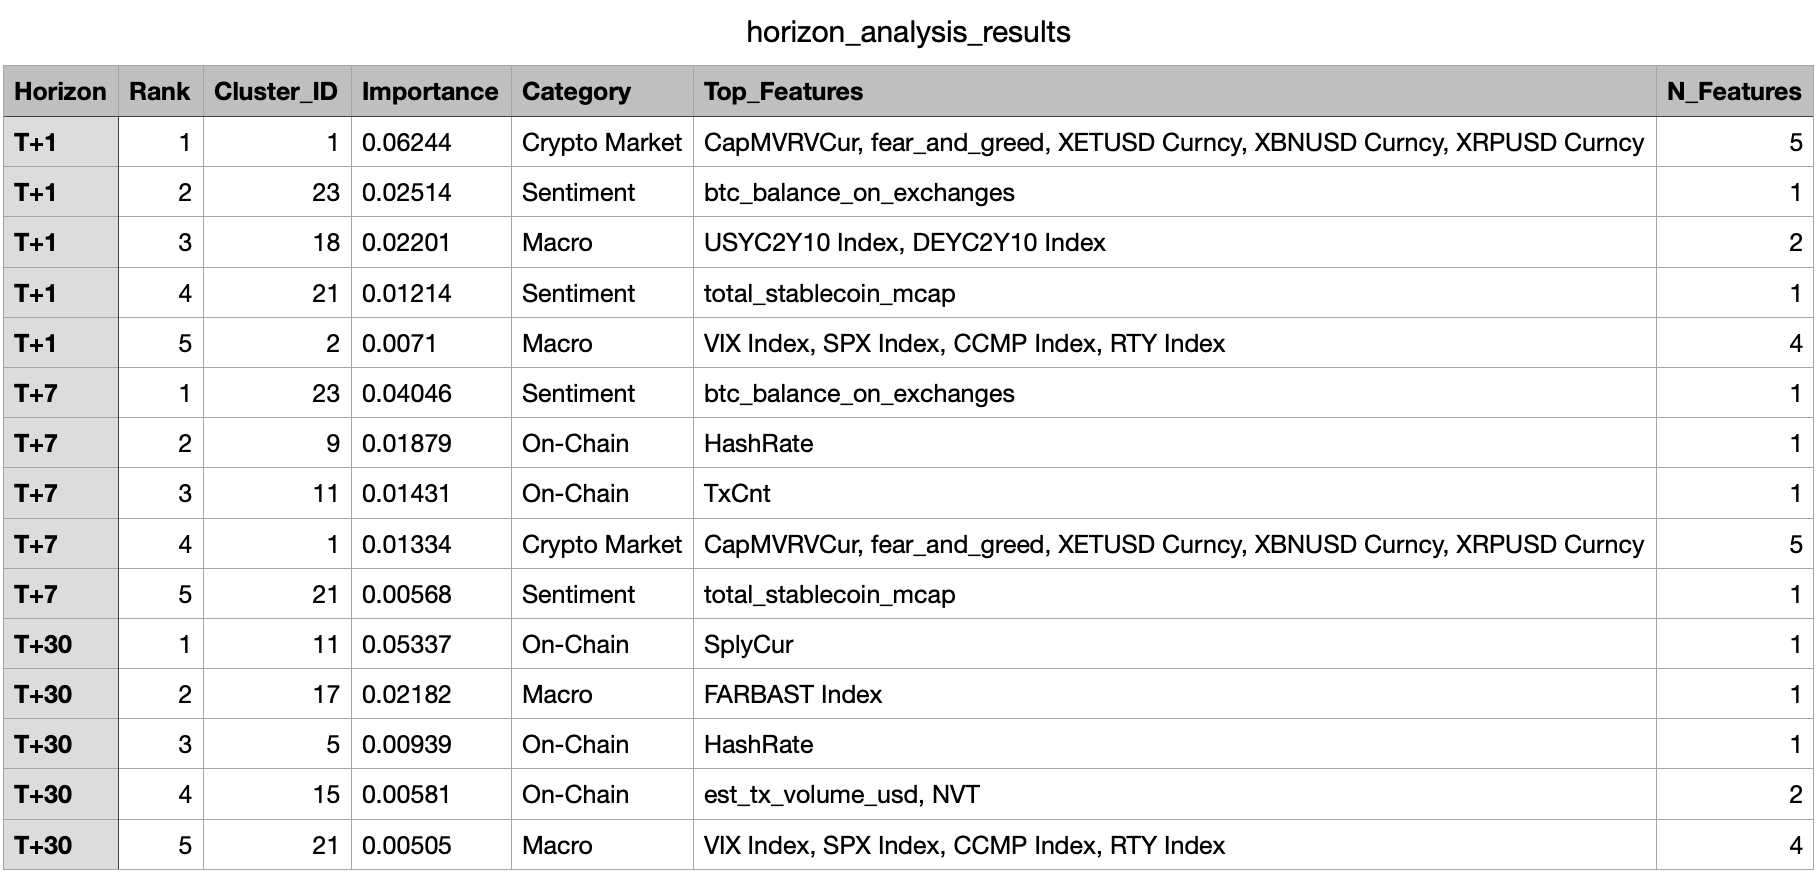

In [ ]:
selected_tickers = list(dict.fromkeys([
    # --- On-Chain (Pillar 1) ---
    'HashRate', 'mining_difficulty', 'miner_revenue_usd', 'hashrate_7d_pct',
    'AdrActCnt', 'TxCnt', 'est_tx_volume_usd', 'avg_block_size',
    'CapMVRVCur', 'NVT', 'SplyCur',
    
    # --- Macro (Pillar 2) ---
    'VIX Index', 'MOVE Index',
    'DXY Curncy',
    'SPX Index', 'CCMP Index', 'RTY Index',
    'USYC2Y10 Index', 'DEYC2Y10 Index',
    'M2 Index', 'FARBAST Index',
    'TFC2RLFS Index', 'CFC5ROIN Index',
    
    # --- Sentiment (Pillar 3) ---
    'fear_and_greed', 'total_stablecoin_mcap', 'btc_balance_on_exchanges',
    'Bitcoin', 'Coinbase', 'BlackRock Bitcoin', 'Buy Bitcoin',
    
    # --- Crypto Market ---
    'XETUSD Curncy', 'XRPUSD Curncy', 'XBNUSD Curncy'
]))


In [101]:
import pandas as pd
import numpy as np
from causallearn.search.ConstraintBased.PC import pc

target_ticker = "XBTUSD Curncy"

# --- Categories for Plotly graph ---
CATEGORY_MAP = {
    'HashRate': 'On-Chain', 'mining_difficulty': 'On-Chain',
    'miner_revenue_usd': 'On-Chain', 'hashrate_7d_pct': 'On-Chain',
    'AdrActCnt': 'On-Chain', 'TxCnt': 'On-Chain', 'TxTfrCnt': 'On-Chain',
    'est_tx_volume_usd': 'On-Chain', 'avg_block_size': 'On-Chain',
    'tx_fees_usd': 'On-Chain', 'CapMVRVCur': 'On-Chain', 'NVT': 'On-Chain',
    'NVT_Signal': 'On-Chain', 'SplyCur': 'On-Chain',
    'VIX Index': 'Macro', 'MOVE Index': 'Macro', 'DXY Curncy': 'Macro',
    'XAU Curncy': 'Macro', 'SPX Index': 'Macro', 'CCMP Index': 'Macro',
    'RTY Index': 'Macro', 'USYC2Y10 Index': 'Macro', 'DEYC2Y10 Index': 'Macro',
    'M2 Index': 'Macro', 'FARBAST Index': 'Macro',
    'TFC2RLFS Index': 'Macro', 'CFC5ROIN Index': 'Macro',
    'fear_and_greed': 'Sentiment', 'total_stablecoin_mcap': 'Sentiment',
    'btc_balance_on_exchanges': 'Sentiment', 'btc_dominance_proxy': 'Sentiment',
    'Bitcoin': 'Sentiment', 'Coinbase': 'Sentiment',
    'BlackRock Bitcoin': 'Sentiment', 'Buy Bitcoin': 'Sentiment',
    'XETUSD Curncy': 'Crypto Market', 'XBNUSD Curncy': 'Crypto Market',
    'XRPUSD Curncy': 'Crypto Market',
    'XBTUSD Curncy': 'BTC (target)',
}
CATEGORY_COLORS = {
    'BTC (target)': '#FFD700', 'On-Chain': '#2ecc71',
    'Macro': '#3498db', 'Sentiment': '#e74c3c', 'Crypto Market': '#9b59b6',
}
def get_category(ticker):
    return CATEGORY_MAP.get(ticker, 'Other')

for key in list(CATEGORY_MAP.keys()):
    CATEGORY_MAP[key + "_chg"] = CATEGORY_MAP[key]

BOUNDED_FEATURES = {
    'fear_and_greed', 'CapMVRVCur', 'NVT', 'NVT_Signal',
    'VIX Index', 'MOVE Index', 'USYC2Y10 Index', 'DEYC2Y10 Index'
}
GOOGLE_TRENDS = {'Bitcoin', 'Coinbase', 'BlackRock Bitcoin', 'Buy Bitcoin'}

# ============================================================
# 1. SELECTION + FILTER
# ============================================================
available_cols = [col for col in selected_tickers if col in pivot_df.columns]
if target_ticker in pivot_df.columns and target_ticker not in available_cols:
    available_cols.append(target_ticker)
available_cols = list(dict.fromkeys(available_cols))

df_sub = pivot_df[available_cols].copy()
df_sub = df_sub[df_sub.index >= "2010-01-01"]
df_sub = df_sub.resample('D').mean()
df_sub = df_sub.dropna(thresh=30, axis=1)

cols = pd.Series(df_sub.columns)
for dup in cols[cols.duplicated()].unique():
    dup_idx = cols[cols == dup].index.tolist()
    for suffix_i, idx in enumerate(dup_idx):
        cols[idx] = f"{dup}_{suffix_i}" if suffix_i > 0 else dup
df_sub.columns = cols

print(f"Columns ({len(df_sub.columns)}): {list(df_sub.columns)}")
print(f"Period: {df_sub.index.min()} -> {df_sub.index.max()}")
print(f"Shape: {df_sub.shape}")

# ============================================================
# 2. FEATURES: LEVELS + CHANGES
# ============================================================
df_levels = df_sub.ffill().copy()

df_changes = pd.DataFrame(index=df_sub.index)
for col in df_sub.columns:
    if col == target_ticker:
        continue  # NO _chg for BTC itself
    if col in BOUNDED_FEATURES or col in GOOGLE_TRENDS:
        df_changes[col + "_chg"] = df_sub[col].diff()
    else:
        df_changes[col + "_chg"] = df_sub[col].pct_change()

df_returns = pd.concat([df_levels, df_changes], axis=1)
df_returns = df_returns.iloc[1:]
df_returns = df_returns.replace([np.inf, -np.inf], np.nan)
df_returns = df_returns.ffill()
df_returns = df_returns.fillna(df_returns.mean())
df_returns = df_returns.dropna(axis=1)

print(f"\nShape with levels + changes: {df_returns.shape}")
print(f"Level columns: {[c for c in df_returns.columns if '_chg' not in c]}")
print(f"Change columns: {[c for c in df_returns.columns if '_chg' in c]}")

# ============================================================
# 3. PC ALGORITHM
# ============================================================
if target_ticker not in df_returns.columns:
    print(f"ERROR: {target_ticker} not in columns!")
else:
    node_names = list(df_returns.columns)
    btc_idx = node_names.index(target_ticker)

    cg = pc(
        df_returns.values,
        alpha=0.05,
        indep_test='fisherz',
        node_names=node_names
    )

    # ============================================================
    # 4. CAUSAL LINKS ANALYSIS
    # ============================================================
    causes = []
    effets = []
    bidirect = []
    nonorient = []

    for i in range(len(node_names)):
        if i == btc_idx:
            continue
        node_i   = cg.G.nodes[i]
        node_btc = cg.G.nodes[btc_idx]
        edge     = cg.G.get_edge(node_i, node_btc)
        if edge is None:
            continue
        ep1 = str(edge.get_endpoint1())
        ep2 = str(edge.get_endpoint2())
        if ep1 == "TAIL" and ep2 == "ARROW":
            causes.append(node_names[i])
        elif ep1 == "ARROW" and ep2 == "TAIL":
            effets.append(node_names[i])
        elif ep1 == "ARROW" and ep2 == "ARROW":
            bidirect.append(node_names[i])
        else:
            nonorient.append(node_names[i])

    print(f"\n{'='*60}")
    print(f"CAUSAL LINKS WITH {target_ticker}")
    print(f"{'='*60}")
    print(f"\nCAUSES ({len(causes)}):")
    for c in causes: print(f"   {c}  -->  BTC")
    print(f"\nEFFECTS ({len(effets)}):")
    for e in effets: print(f"   BTC  -->  {e}")
    print(f"\nBIDIRECTIONAL ({len(bidirect)}):")
    for b in bidirect: print(f"   {b}  <-->  BTC")
    print(f"\nUNORIENTED ({len(nonorient)}):")
    for n in nonorient: print(f"   {n}  --  BTC")
    print(f"\nTOTAL: {len(causes)} cause(s), {len(effets)} effect(s), "
          f"{len(bidirect)} bidirectional, {len(nonorient)} unoriented")

Columns (26): ['HashRate', 'mining_difficulty', 'miner_revenue_usd', 'hashrate_7d_pct', 'AdrActCnt', 'TxCnt', 'est_tx_volume_usd', 'avg_block_size', 'CapMVRVCur', 'NVT', 'SplyCur', 'VIX Index', 'MOVE Index', 'DXY Curncy', 'SPX Index', 'CCMP Index', 'RTY Index', 'USYC2Y10 Index', 'DEYC2Y10 Index', 'M2 Index', 'FARBAST Index', 'TFC2RLFS Index', 'CFC5ROIN Index', 'XETUSD Curncy', 'XRPUSD Curncy', 'XBTUSD Curncy']
Period: 2010-01-01 00:00:00 -> 2025-11-04 00:00:00
Shape: (5787, 26)

Shape with levels + changes: (5786, 51)
Level columns: ['HashRate', 'mining_difficulty', 'miner_revenue_usd', 'hashrate_7d_pct', 'AdrActCnt', 'TxCnt', 'est_tx_volume_usd', 'avg_block_size', 'CapMVRVCur', 'NVT', 'SplyCur', 'VIX Index', 'MOVE Index', 'DXY Curncy', 'SPX Index', 'CCMP Index', 'RTY Index', 'USYC2Y10 Index', 'DEYC2Y10 Index', 'M2 Index', 'FARBAST Index', 'TFC2RLFS Index', 'CFC5ROIN Index', 'XETUSD Curncy', 'XRPUSD Curncy', 'XBTUSD Curncy']
Change columns: ['HashRate_chg', 'mining_difficulty_chg', 'mi

C:\Users\marce\AppData\Local\Temp\ipykernel_5476\3524389287.py:80: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\marce\AppData\Local\Temp\ipykernel_5476\3524389287.py:80: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\marce\AppData\Local\Temp\ipykernel_5476\3524389287.py:80: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\marce\AppData\Local\Temp\ipykernel_5476\3524389287.py:8

  0%|          | 0/51 [00:00<?, ?it/s]


CAUSAL LINKS WITH XBTUSD Curncy

CAUSES (5):
   mining_difficulty  -->  BTC
   miner_revenue_usd  -->  BTC
   est_tx_volume_usd  -->  BTC
   CCMP Index  -->  BTC
   XRPUSD Curncy  -->  BTC

EFFECTS (0):

BIDIRECTIONAL (0):

UNORIENTED (0):

TOTAL: 5 cause(s), 0 effect(s), 0 bidirectional, 0 unoriented


**Interactive Causal Graph Alvaro test**


In [102]:
import plotly.graph_objects as go
import networkx as nx
import numpy as np


def plot_dag_arrows(cg_object, nodes, df_returns, causes, effets, bidirect, target_ticker):
    """
    cg_object: le cg.G retourné par causallearn (PAS adj_matrix)
    """

    G = nx.DiGraph()

    # Construire le graphe depuis l'objet causallearn (PAS depuis adj_matrix)
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            node_i = cg_object.nodes[i]
            node_j = cg_object.nodes[j]
            edge = cg_object.get_edge(node_i, node_j)
            if edge is None:
                continue
            ep1 = str(edge.get_endpoint1())  # côté node_i
            ep2 = str(edge.get_endpoint2())  # côté node_j

            if ep1 == "TAIL" and ep2 == "ARROW":
                G.add_edge(nodes[i], nodes[j])  # i → j
            elif ep1 == "ARROW" and ep2 == "TAIL":
                G.add_edge(nodes[j], nodes[i])  # j → i
            elif ep1 == "ARROW" and ep2 == "ARROW":
                G.add_edge(nodes[i], nodes[j])
                G.add_edge(nodes[j], nodes[i])
            else:
                # Non orienté — on met les deux directions
                G.add_edge(nodes[i], nodes[j])
                G.add_edge(nodes[j], nodes[i])

    btc_neighbors = set(G.predecessors(target_ticker)) | set(G.successors(target_ticker))
    btc_neighbors.add(target_ticker)

    pos = nx.spring_layout(G, seed=42, k=2.5)
    pos[target_ticker] = np.array([0.0, 1.2])
    corr_matrix = np.abs(np.corrcoef(df_returns.values.T))

    all_traces = []
    vis_all = []
    vis_btc_only = []

    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        idx_u = nodes.index(u) if u in nodes else -1
        idx_v = nodes.index(v) if v in nodes else -1
        weight = corr_matrix[idx_u, idx_v] if idx_u >= 0 and idx_v >= 0 else 0.3
        alpha = max(0.1, min(1.0, weight * 1.5))
        cat_u, cat_v = get_category(u), get_category(v)
        is_btc_edge = (u == target_ticker or v == target_ticker)

        # u → v : si v est BTC, c'est une cause (vert)
        #         si u est BTC, c'est un effet (orange)
        if v == target_ticker:
            rgba  = f"rgba(0, 160, 0, {alpha})"
            solid = "rgb(0, 160, 0)"
            width = 2.5
        elif u == target_ticker:
            rgba  = f"rgba(220, 120, 0, {alpha})"
            solid = "rgb(220, 120, 0)"
            width = 2.0
        else:
            rgba  = f"rgba(120, 120, 120, {alpha})"
            solid = "rgb(120, 120, 120)"
            width = 1.0

        if cat_u == "BTC (target)":    edge_groups = [cat_v]
        elif cat_v == "BTC (target)":  edge_groups = [cat_u]
        else:                          edge_groups = [cat_u]

        # Triangle de flèche : pointe vers v (la destination)
        dx, dy = x1 - x0, y1 - y0
        length = np.sqrt(dx**2 + dy**2)
        if length > 0:
            ux_n, uy_n = dx / length, dy / length
            tip_x = x1 - ux_n * 0.04
            tip_y = y1 - uy_n * 0.04
            perp_x, perp_y = -uy_n, ux_n
            arrow_size = 0.018
            base1_x = tip_x - ux_n * 0.025 + perp_x * arrow_size
            base1_y = tip_y - uy_n * 0.025 + perp_y * arrow_size
            base2_x = tip_x - ux_n * 0.025 - perp_x * arrow_size
            base2_y = tip_y - uy_n * 0.025 - perp_y * arrow_size
        else:
            tip_x, tip_y = x1, y1
            base1_x, base1_y = x1, y1
            base2_x, base2_y = x1, y1

        for grp in edge_groups:
            # Ligne
            all_traces.append(go.Scatter(
                x=[x0, x1, None], y=[y0, y1, None], mode='lines',
                line=dict(width=width, color=rgba),
                hoverinfo='none', showlegend=False, legendgroup=grp))
            vis_all.append(True)
            vis_btc_only.append(is_btc_edge)

            # Pointe de flèche (triangle)
            all_traces.append(go.Scatter(
                x=[tip_x, base1_x, base2_x, tip_x, None],
                y=[tip_y, base1_y, base2_y, tip_y, None],
                mode='lines', fill='toself',
                fillcolor=solid, line=dict(width=0, color=solid),
                hoverinfo='none', showlegend=False, legendgroup=grp))
            vis_all.append(True)
            vis_btc_only.append(is_btc_edge)

    # --- NODES ---
    for cat, color in CATEGORY_COLORS.items():
        cat_nodes = [n for n in G.nodes() if get_category(n) == cat]
        if not cat_nodes: continue
        cx, cy, csizes, ctext, chover, cborders, cborder_w = [], [], [], [], [], [], []
        for node in cat_nodes:
            x, y = pos[node]
            cx.append(x); cy.append(y)
            in_e = list(G.predecessors(node))
            out_e = list(G.successors(node))
            chover.append(
                f"<b>{node}</b><br>Category: {cat}<br>"
                f"Receives from: {len(in_e)} nodes<br>Sends to: {len(out_e)} nodes<br>"
                f"Connections: {', '.join(in_e + out_e) if in_e + out_e else 'none'}")
            ctext.append(node.replace(" Index","").replace(" Curncy","").replace("_chg"," (chg)"))
            if node == target_ticker:
                csizes.append(45); cborders.append("#FFD700"); cborder_w.append(5)
            elif node in causes:
                csizes.append(35); cborders.append("#00CC00"); cborder_w.append(4)
            elif node in effets:
                csizes.append(35); cborders.append("#FF6600"); cborder_w.append(4)
            elif node in bidirect:
                csizes.append(35); cborders.append("#CC00CC"); cborder_w.append(4)
            else:
                csizes.append(25); cborders.append("#999999"); cborder_w.append(1.5)
        has_btc = any(n in btc_neighbors for n in cat_nodes)
        lg = '_noclick' if cat == "BTC (target)" else cat
        all_traces.append(go.Scatter(
            x=cx, y=cy, mode='markers+text', name=cat,
            text=ctext, textposition='top center',
            textfont=dict(size=9, color='#333333'),
            hovertext=chover, hoverinfo='text',
            marker=dict(size=csizes, color=color,
                        line=dict(color=cborders, width=cborder_w), opacity=0.95),
            legendgroup=lg, showlegend=True))
        vis_all.append(True)
        vis_btc_only.append(True if cat == "BTC (target)" or has_btc else False)

    # --- LEGEND ---
    for t in [
        go.Scatter(x=[None],y=[None],mode='markers',
            marker=dict(size=10,color='gray',line=dict(color='#00CC00',width=3)),
            name='Cause -> BTC',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='markers',
            marker=dict(size=10,color='gray',line=dict(color='#FF6600',width=3)),
            name='BTC -> Effect',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='lines',
            line=dict(color='rgba(0,160,0,0.8)',width=2.5),
            name='Edge -> BTC (green)',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='lines',
            line=dict(color='rgba(220,120,0,0.8)',width=2),
            name='Edge BTC -> (orange)',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='lines',
            line=dict(color='rgba(120,120,120,0.3)',width=1),
            name='Other link (grey)',showlegend=True,legendgroup='_noclick'),
    ]:
        all_traces.append(t); vis_all.append(True); vis_btc_only.append(True)

    fig = go.Figure(data=all_traces, layout=go.Layout(
        title=dict(text=("<b>PC Algorithm — Causal Graph Alvaro Test</b><br>"
            "<sub>Click legend = hide/show category | Double click = isolate | "
            "Hover for details | Use button to filter BTC links</sub>"),
            font=dict(size=15, color='#333333'), x=0.5),
        paper_bgcolor='white', plot_bgcolor='white', showlegend=True,
        legend=dict(bgcolor='rgba(0,0,0,0.05)', bordercolor='rgba(0,0,0,0.2)',
            borderwidth=1, font=dict(color='#333333', size=9),
            x=0.01, y=0.99, groupclick='togglegroup'),
        hovermode='closest',
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        margin=dict(l=20, r=20, t=90, b=20), height=850,
        updatemenus=[dict(type="buttons", direction="left",
            x=0.99, y=1.02, xanchor="right", yanchor="bottom",
            buttons=[
                dict(label="Show all", method="update",
                     args=[{"visible": vis_all}]),
                dict(label="BTC links only", method="update",
                     args=[{"visible": vis_btc_only}]),
            ], bgcolor="white", bordercolor="#999", font=dict(size=11))],
    ))
    import webbrowser, os
    filepath = os.path.abspath("causal_graph_arrows.html")
    fig.write_html(filepath, include_plotlyjs=True)
    fig.show()
    webbrowser.open("file://" + filepath)

# APPEL — on passe cg.G (pas cg.G.graph)
plot_dag_arrows(cg.G, node_names, df_returns, causes, effets, bidirect, target_ticker)

**Random Forest — Test 3 (Alvaro pillars)**


In [103]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier

START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"
HORIZONS = [1, 7, 14, 30, 60]
N_BINS = 3
MIN_NON_NA_FRAC = 0.70
MIN_ROWS = 300

RF_PARAMS = dict(
    n_estimators=400, max_depth=12, min_samples_split=10,
    min_samples_leaf=5, max_features="sqrt",
    class_weight="balanced", random_state=42, n_jobs=-1)

CAUSAL_VARS = causes.copy()
CAUSAL_VARS_EXTENDED = []
for v in CAUSAL_VARS:
    CAUSAL_VARS_EXTENDED.append(v)
    if v + "_chg" in df_returns.columns:
        CAUSAL_VARS_EXTENDED.append(v + "_chg")
CAUSAL_VARS_EXTENDED = list(set(CAUSAL_VARS_EXTENDED))
print(f"Causal vars (PC): {CAUSAL_VARS}")
print(f"Causal vars extended: {CAUSAL_VARS_EXTENDED}")

def calculate_returns(prices, horizon):
    return (prices.shift(-horizon) - prices) / prices

def fit_bins(train_ret, n=3):
    qs = np.quantile(train_ret.dropna().values, np.linspace(0, 1, n+1))
    qs[0], qs[-1] = -np.inf, np.inf
    for i in range(1, len(qs)):
        if qs[i] <= qs[i-1]: qs[i] = qs[i-1] + 1e-12
    return qs

def run_rf(pivot_df, feature_cols, horizon, label=""):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(START_DATE)]
    btc_col = "XBTUSD Curncy"
    if btc_col not in df.columns: return None
    ret = calculate_returns(df[btc_col].astype(float), horizon)
    feats = [c for c in feature_cols if c in df.columns and c != btc_col]
    if len(feats) < 3: return None
    df_m = df[feats].ffill().copy()
    thresh = int(MIN_NON_NA_FRAC * len(df_m))
    df_m = df_m.dropna(axis=1, thresh=thresh)
    feats = list(df_m.columns)
    df_m["target"] = ret
    df_m = df_m.dropna(subset=["target"])
    cut = pd.to_datetime(TRAIN_END_DATE)
    tr = df_m[df_m.index <= cut]
    te = df_m[df_m.index > cut]
    if len(tr) < MIN_ROWS or len(te) < 50: return None
    bins = fit_bins(tr["target"], N_BINS)
    y_tr = pd.cut(tr["target"], bins=bins, labels=False).dropna().astype(int)
    y_te = pd.cut(te["target"], bins=bins, labels=False).dropna().astype(int)
    X_tr = tr[feats].loc[y_tr.index]
    X_te = te[feats].loc[y_te.index]
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    clf = RandomForestClassifier(**RF_PARAMS)
    clf.fit(X_tr_s, y_tr)
    y_pred = clf.predict(X_te_s)
    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_tr_s, y_tr)
    y_dum = dummy.predict(X_te_s)
    imp = pd.DataFrame({"feature": feats, "importance": clf.feature_importances_})
    imp = imp.sort_values("importance", ascending=False).reset_index(drop=True)
    imp["rank"] = np.arange(1, len(imp)+1)
    return {
        "label": label, "horizon": horizon, "n_features": len(feats),
        "n_train": len(y_tr), "n_test": len(y_te),
        "acc": accuracy_score(y_te, y_pred),
        "bal_acc": balanced_accuracy_score(y_te, y_pred),
        "macro_f1": f1_score(y_te, y_pred, average="macro"),
        "cm": confusion_matrix(y_te, y_pred, labels=list(range(N_BINS))),
        "dummy_acc": accuracy_score(y_te, y_dum),
        "dummy_bal_acc": balanced_accuracy_score(y_te, y_dum),
        "imp_full": imp, "features_used": feats,
    }

all_features = [c for c in pivot_df.columns if c != "XBTUSD Curncy"]
results_all_3 = []
results_causal_3 = []

for h in HORIZONS:
    print(f"\n{{'='*70}}")
    print(f"HORIZON = {{h}} days")
    print(f"{{'='*70}}")

    ra = run_rf(pivot_df, all_features, h, "All variables")
    if ra:
        results_all_3.append(ra)
        print(f"  ALL VARS     -> Acc={{ra['acc']*100:.1f}}% | BalAcc={{ra['bal_acc']*100:.1f}}% | F1={{ra['macro_f1']:.3f}} | {{ra['n_features']}} feats")

    rc = run_rf(pivot_df, CAUSAL_VARS_EXTENDED, h, "Causal only")
    if rc:
        results_causal_3.append(rc)
        print(f"  CAUSAL ONLY  -> Acc={{rc['acc']*100:.1f}}% | BalAcc={{rc['bal_acc']*100:.1f}}% | F1={{rc['macro_f1']:.3f}} | {{rc['n_features']}} feats")

    if ra and rc:
        d = (rc['acc'] - ra['acc']) * 100
        print(f"  DELTA        -> Acc: {{d:+.1f}}pp | F1: {{rc['macro_f1']-ra['macro_f1']:+.3f}}")

all_res = results_all_3 + results_causal_3
if all_res:
    s = pd.DataFrame([{
        "Model": r["label"], "Horizon": r["horizon"],
        "Features": r["n_features"],
        "Acc (%)": round(r["acc"]*100,1),
        "BalAcc (%)": round(r["bal_acc"]*100,1),
        "F1": round(r["macro_f1"],3),
        "Dummy Acc (%)": round(r["dummy_acc"]*100,1),
    } for r in all_res]).sort_values(["Horizon","Model"])
    print(f"\n{'='*70}")
    print("COMPARISON: ALL VARIABLES vs CAUSAL ONLY")
    print(f"{'='*70}")
    print(s.to_string(index=False))


Causal vars (PC): ['mining_difficulty', 'miner_revenue_usd', 'est_tx_volume_usd', 'CCMP Index', 'XRPUSD Curncy']
Causal vars extended: ['est_tx_volume_usd', 'mining_difficulty_chg', 'CCMP Index_chg', 'miner_revenue_usd', 'XRPUSD Curncy_chg', 'CCMP Index', 'XRPUSD Curncy', 'mining_difficulty', 'est_tx_volume_usd_chg', 'miner_revenue_usd_chg']

{'='*70}
HORIZON = {h} days
{'='*70}
  ALL VARS     -> Acc={ra['acc']*100:.1f}% | BalAcc={ra['bal_acc']*100:.1f}% | F1={ra['macro_f1']:.3f} | {ra['n_features']} feats
  CAUSAL ONLY  -> Acc={rc['acc']*100:.1f}% | BalAcc={rc['bal_acc']*100:.1f}% | F1={rc['macro_f1']:.3f} | {rc['n_features']} feats
  DELTA        -> Acc: {d:+.1f}pp | F1: {rc['macro_f1']-ra['macro_f1']:+.3f}

{'='*70}
HORIZON = {h} days
{'='*70}
  ALL VARS     -> Acc={ra['acc']*100:.1f}% | BalAcc={ra['bal_acc']*100:.1f}% | F1={ra['macro_f1']:.3f} | {ra['n_features']} feats
  CAUSAL ONLY  -> Acc={rc['acc']*100:.1f}% | BalAcc={rc['bal_acc']*100:.1f}% | F1={rc['macro_f1']:.3f} | {rc['n_f

### Test PC for all features

In [104]:
import pandas as pd
import numpy as np
from causallearn.search.ConstraintBased.PC import pc

target_ticker = "XBTUSD Curncy"

# ============================================================
# CATEGORY MAP (complete)
# ============================================================
CATEGORY_MAP = {
    # On-Chain
    'HashRate': 'On-Chain', 'mining_difficulty': 'On-Chain',
    'miner_revenue_usd': 'On-Chain', 'hashrate_7d_pct': 'On-Chain',
    'difficulty_14d_pct': 'On-Chain',
    'AdrActCnt': 'On-Chain', 'TxCnt': 'On-Chain', 'TxTfrCnt': 'On-Chain',
    'est_tx_volume_usd': 'On-Chain', 'avg_block_size': 'On-Chain',
    'BlkCnt': 'On-Chain', 'tx_per_block': 'On-Chain', 'tx_per_second': 'On-Chain',
    'n_tx_excl_popular': 'On-Chain', 'tx_fees_usd': 'On-Chain', 'cost_per_tx_usd': 'On-Chain',
    'active_addr_ratio': 'On-Chain',
    'mempool_count': 'On-Chain', 'mempool_growth': 'On-Chain', 'mempool_size_bytes': 'On-Chain',
    'median_confirm_time': 'On-Chain', 'avg_confirm_time': 'On-Chain',
    'CapMVRVCur': 'On-Chain', 'NVT': 'On-Chain', 'NVT_Signal': 'On-Chain',
    'SplyCur': 'On-Chain', 'utxo_count': 'On-Chain',
    'price_usd': 'On-Chain', 'market_cap_usd': 'On-Chain',
    'ln_channel_count': 'On-Chain', 'ln_capacity_sat': 'On-Chain', 'btc_commits_weekly': 'On-Chain',
    'days_to_next_halving': 'On-Chain', 'days_since_halving': 'On-Chain',
    'RIOT US Equity': 'On-Chain', 'MARA US Equity': 'On-Chain',
    'CIFR US Equity': 'On-Chain', 'IREN US Equity': 'On-Chain', 'CORZ US Equity': 'On-Chain',
    # Macro
    'VIX Index': 'Macro', 'MOVE Index': 'Macro', 'CVIX Index': 'Macro',
    'DXY Curncy': 'Macro', 'EURUSD Curncy': 'Macro', 'JPYUSD Curncy': 'Macro',
    'CNH Curncy': 'Macro', 'JPMVXYGL Index': 'Macro',
    'SPX Index': 'Macro', 'CCMP Index': 'Macro', 'RTY Index': 'Macro',
    'SXXP Index': 'Macro', 'SHCOMP Index': 'Macro', 'NKY Index': 'Macro',
    'XAU Curncy': 'Macro', 'CRY Index': 'Macro', 'SPGSCITR Index': 'Macro',
    'CL1 COMB Comdty': 'Macro', 'CO1 COMB Comdty': 'Macro', 'NG1 COMB Comdty': 'Macro',
    'BDIY Index': 'Macro',
    'LUATTRUU Index': 'Macro', 'LUACTRUU Index': 'Macro', 'LF98TRUU Index': 'Macro',
    'USYC2Y10 Index': 'Macro', 'DEYC2Y10 Index': 'Macro', 'JPYC2Y10 Index': 'Macro',
    'USGG3M Index': 'Macro', 'GJGB3M Index': 'Macro', 'GCNY3M Index': 'Macro',
    'EURR002W Index': 'Macro', 'FDTR Index': 'Macro', 'BOJDPBAL Index': 'Macro',
    'CHRRDEPC Index': 'Macro', 'BASPTDSP Index': 'Macro', 'GETB1 Index': 'Macro',
    'M2 Index': 'Macro', 'ECMAM2 Index': 'Macro', 'JMNSM2SA Index': 'Macro', 'CNMSM2 Index': 'Macro',
    'FARBAST Index': 'Macro', 'EBBSTOTA Index': 'Macro', 'CNBMTTAS Index': 'Macro',
    'WGDPEURO Index': 'Macro', 'WGDPUS Index': 'Macro', 'WGDPJAPA Index': 'Macro', 'WGDPCHIN Index': 'Macro',
    'EUITEMU Index': 'Macro', 'IP Index': 'Macro', 'JNIPNSA Index': 'Macro', 'CHVAICY Index': 'Macro',
    'RSSAEMU Index': 'Macro', 'OEUSZRER Index': 'Macro', 'OEJPZRER Index': 'Macro', 'CNRSCONS Index': 'Macro',
    'CPEXEMUY Index': 'Macro', 'CPI XYOY Index': 'Macro', 'JCPNEFEY Index': 'Macro', 'CNCPCRY Index': 'Macro',
    'IUTPELC Index': 'Macro',
    'CESIEUR Index': 'Macro', 'CESIUSD Index': 'Macro', 'CESIJPY Index': 'Macro', 'CESICNY Index': 'Macro',
    'News-based Economic Policy Uncertainty Index': 'Macro',
    'European_News_Index': 'Macro', 'France_News_Index': 'Macro',
    'Germany_News_Index': 'Macro', 'Italy_News_Index': 'Macro',
    'UK_News_Index': 'Macro', 'Spain_News_Index': 'Macro',
    'News_Based_Policy_Uncert_Index': 'Macro',
    'TSEMIL Index': 'Macro', 'SOX Index': 'Macro',
    'TFC2RLFS Index': 'Macro', 'CFC5ROIN Index': 'Macro',
    'CFC5QOIN Index': 'Macro', 'CFF5QOIN Index': 'Macro', 'CFC5QNCN Index': 'Macro',
    'CFF5ROIN Index': 'Macro', 'CFF5RNCN Index': 'Macro', 'CFC5RNCN Index': 'Macro',
    'TFF2RLFN Index': 'Macro', 'CFF5RTLL Index': 'Macro', 'CFF5RTLN Index': 'Macro',
    'TFC2RDIN Index': 'Macro', 'CFF5RNRN Index': 'Macro', 'TFC2RLFN Index': 'Macro',
    'CFF5RNCL Index': 'Macro', 'CFF5RCON Index': 'Macro', 'CFF5RTLS Index': 'Macro',
    'TFC2RAIN Index': 'Macro', 'CFF5RNCS Index': 'Macro', 'CFC5RCOL Index': 'Macro',
    'CFC5RTCL Index': 'Macro', 'TFF2RLFD Index': 'Macro', 'TFF2RORN Index': 'Macro',
    'TFC2RORS Index': 'Macro', 'TFF2RAIN Index': 'Macro',
    # Sentiment
    'fear_and_greed': 'Sentiment', 'btc_balance_on_exchanges': 'Sentiment',
    'total_stablecoin_mcap': 'Sentiment', 'btc_dominance_proxy': 'Sentiment',
    'Trezor': 'Sentiment', 'Trust Wallet': 'Sentiment', 'Uniswap': 'Sentiment',
    'PancakeSwap': 'Sentiment', 'Cold Storage': 'Sentiment',
    'Binance': 'Sentiment', 'Coinbase': 'Sentiment', 'Kraken': 'Sentiment',
    'Metamask': 'Sentiment', 'Ledger': 'Sentiment',
    'BlackRock Bitcoin': 'Sentiment', 'Bitcoin ETF': 'Sentiment',
    'SEC Crypto': 'Sentiment', 'Gary Gensler': 'Sentiment', 'MicroStrategy': 'Sentiment',
    'Inflation': 'Sentiment', 'Recession': 'Sentiment',
    'Interest Rates': 'Sentiment', 'Fed Meeting': 'Sentiment', 'Banking Crisis': 'Sentiment',
    'Ethereum': 'Sentiment', 'Tether': 'Sentiment', 'USDC': 'Sentiment',
    'Solana': 'Sentiment', 'XRP': 'Sentiment',
    'Bull Run': 'Sentiment', 'Bear Market': 'Sentiment',
    'To The Moon': 'Sentiment', 'Rekt': 'Sentiment', 'FOMO': 'Sentiment',
    'Bitcoin': 'Sentiment', 'Crypto': 'Sentiment', 'Buy Bitcoin': 'Sentiment',
    'Altcoin': 'Sentiment', 'HODL': 'Sentiment',
    'Crypto Hack': 'Sentiment', 'Rug Pull': 'Sentiment',
    'Private Key': 'Sentiment', 'Seed Phrase': 'Sentiment', 'Crypto Tax': 'Sentiment',
    'Bitcoin Mining': 'Sentiment', 'Hashrate': 'Sentiment', 'Bitcoin Halving': 'Sentiment',
    'Satoshi Nakamoto': 'Sentiment', 'Blockchain': 'Sentiment',
    'Elon Musk Bitcoin': 'Sentiment', 'Michael Saylor': 'Sentiment',
    'Vitalik Buterin': 'Sentiment', 'PlanB': 'Sentiment', 'Cathie Wood': 'Sentiment',
    # Crypto Market
    'XETUSD Curncy': 'Crypto Market', 'XBNUSD Curncy': 'Crypto Market',
    'XRPUSD Curncy': 'Crypto Market', 'XLCUSD Curncy': 'Crypto Market',
    'XDGUSD Curncy': 'Crypto Market', 'XADUSD Curncy': 'Crypto Market',
    'XSOUSD Curncy': 'Crypto Market',
    # BTC
    'XBTUSD Curncy': 'BTC (target)',
}
CATEGORY_COLORS = {
    'BTC (target)': '#FFD700', 'On-Chain': '#2ecc71',
    'Macro': '#3498db', 'Sentiment': '#e74c3c', 'Crypto Market': '#9b59b6',
}
def get_category(ticker):
    return CATEGORY_MAP.get(ticker, 'Other')

BOUNDED_FEATURES = {
    'fear_and_greed', 'CapMVRVCur', 'NVT', 'NVT_Signal',
    'VIX Index', 'MOVE Index', 'USYC2Y10 Index', 'DEYC2Y10 Index'
}
GOOGLE_TRENDS = {
    'Bitcoin', 'Coinbase', 'BlackRock Bitcoin', 'Buy Bitcoin',
    'Trezor', 'Trust Wallet', 'Uniswap', 'PancakeSwap', 'Cold Storage',
    'Binance', 'Kraken', 'Metamask', 'Ledger', 'Bitcoin ETF', 'SEC Crypto',
    'Gary Gensler', 'MicroStrategy', 'Inflation', 'Recession',
    'Interest Rates', 'Fed Meeting', 'Banking Crisis', 'Ethereum', 'Tether',
    'USDC', 'Solana', 'XRP', 'Bull Run', 'Bear Market', 'To The Moon',
    'Rekt', 'FOMO', 'Crypto', 'Buy Bitcoin', 'Altcoin', 'HODL',
    'Crypto Hack', 'Rug Pull', 'Private Key', 'Seed Phrase', 'Crypto Tax',
    'Bitcoin Mining', 'Hashrate', 'Bitcoin Halving', 'Satoshi Nakamoto',
    'Blockchain', 'Elon Musk Bitcoin', 'Michael Saylor', 'Vitalik Buterin',
    'PlanB', 'Cathie Wood',
}

# ============================================================
# 1. ALL FEATURES FROM PIVOT_DF
# ============================================================
all_cols = list(pivot_df.columns)
df_sub = pivot_df[all_cols].copy()
df_sub = df_sub[df_sub.index >= "2015-01-01"]
df_sub = df_sub.resample('D').mean()
df_sub = df_sub.ffill()
df_sub = df_sub.dropna(axis=1, thresh=int(0.7 * len(df_sub)))

print(f"Columns after filter: {len(df_sub.columns)}")
print(f"Period: {df_sub.index.min()} -> {df_sub.index.max()}")

# ============================================================
# 2. VARIATIONS ONLY (stationarity)
# ============================================================
changes = {}
for col in df_sub.columns:
    if col in BOUNDED_FEATURES or col in GOOGLE_TRENDS:
        changes[col] = df_sub[col].diff()
    else:
        changes[col] = df_sub[col].pct_change()

df_pc_all = pd.DataFrame(changes, index=df_sub.index)
df_pc_all = df_pc_all.iloc[1:]
df_pc_all = df_pc_all.replace([np.inf, -np.inf], np.nan)
df_pc_all = df_pc_all.ffill()
df_pc_all = df_pc_all.fillna(df_pc_all.mean())
df_pc_all = df_pc_all.dropna(axis=1)

print(f"Shape after variations: {df_pc_all.shape}")

# ============================================================
# 3. REMOVE REDUNDANT COLUMNS (fix singular matrix)
# ============================================================
# Zero variance
std = df_pc_all.std()
zero_var = std[std < 1e-10].index.tolist()
if zero_var:
    print(f"Removed {len(zero_var)} zero-variance columns")
    df_pc_all = df_pc_all.drop(columns=zero_var)

# Highly correlated (>0.98)
corr = df_pc_all.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = set()
for col in upper.columns:
    highly_corr = upper.index[upper[col] > 0.98].tolist()
    for hc in highly_corr:
        if hc != target_ticker:
            to_drop.add(hc)

if to_drop:
    print(f"Removed {len(to_drop)} highly correlated columns (>0.98)")
    df_pc_all = df_pc_all.drop(columns=list(to_drop))

# Near-constant
df_pc_all = df_pc_all.loc[:, df_pc_all.nunique() > 10]

print(f"Final shape for PC: {df_pc_all.shape}")

# ============================================================
# 4. PC ALGORITHM
# ============================================================
node_names = list(df_pc_all.columns)
btc_idx = node_names.index(target_ticker)

print(f"\nRunning PC on {len(node_names)} features... (may take a few minutes)")

cg = pc(
    df_pc_all.values,
    alpha=0.05,
    indep_test='fisherz',
    node_names=node_names
)

# ============================================================
# 5. CAUSAL LINKS ANALYSIS
# ============================================================
causes = []
effets = []
bidirect = []
nonorient = []

for i in range(len(node_names)):
    if i == btc_idx:
        continue
    node_i   = cg.G.nodes[i]
    node_btc = cg.G.nodes[btc_idx]
    edge     = cg.G.get_edge(node_i, node_btc)
    if edge is None:
        continue
    ep1 = str(edge.get_endpoint1())
    ep2 = str(edge.get_endpoint2())
    if ep1 == "TAIL" and ep2 == "ARROW":
        causes.append(node_names[i])
    elif ep1 == "ARROW" and ep2 == "TAIL":
        effets.append(node_names[i])
    elif ep1 == "ARROW" and ep2 == "ARROW":
        bidirect.append(node_names[i])
    else:
        nonorient.append(node_names[i])

print(f"\n{'='*60}")
print(f"CAUSAL LINKS WITH {target_ticker}")
print(f"Features tested: {len(node_names)}")
print(f"{'='*60}")

print(f"\nCAUSES ({len(causes)}):")
for c in causes:
    print(f"   {c:40s} [{get_category(c)}]  -->  BTC")

print(f"\nEFFECTS ({len(effets)}):")
for e in effets:
    print(f"   BTC  -->  {e:40s} [{get_category(e)}]")

print(f"\nBIDIRECTIONAL ({len(bidirect)}):")
for b in bidirect:
    print(f"   {b:40s} [{get_category(b)}]  <-->  BTC")

print(f"\nUNORIENTED ({len(nonorient)}):")
for n in nonorient:
    print(f"   {n:40s} [{get_category(n)}]  --  BTC")

print(f"\n{'='*60}")
print(f"TOTAL: {len(causes)} cause(s), {len(effets)} effect(s), "
      f"{len(bidirect)} bidirectional, {len(nonorient)} unoriented")
print(f"{'='*60}")

from collections import Counter
print(f"\nBREAKDOWN BY CATEGORY:")
all_linked = causes + effets + bidirect + nonorient
cat_counts = Counter(get_category(f) for f in all_linked)
for cat, count in sorted(cat_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"   {cat:20s}: {count} link(s)")

Columns after filter: 117
Period: 2015-01-01 00:00:00 -> 2025-11-04 00:00:00
Shape after variations: (3960, 117)
Removed 4 highly correlated columns (>0.98)
Final shape for PC: (3960, 112)

Running PC on 112 features... (may take a few minutes)


  0%|          | 0/112 [00:00<?, ?it/s]


CAUSAL LINKS WITH XBTUSD Curncy
Features tested: 112

CAUSES (8):
   CFF5QOIN Index                           [Macro]  -->  BTC
   CapMVRVCur                               [On-Chain]  -->  BTC
   RIOT US Equity                           [On-Chain]  -->  BTC
   XBNUSD Curncy                            [Crypto Market]  -->  BTC
   XETUSD Curncy                            [Crypto Market]  -->  BTC
   XLCUSD Curncy                            [Crypto Market]  -->  BTC
   market_cap_usd                           [On-Chain]  -->  BTC
   miner_revenue_usd                        [On-Chain]  -->  BTC

EFFECTS (0):

BIDIRECTIONAL (0):

UNORIENTED (0):

TOTAL: 8 cause(s), 0 effect(s), 0 bidirectional, 0 unoriented

BREAKDOWN BY CATEGORY:
   On-Chain            : 4 link(s)
   Crypto Market       : 3 link(s)
   Macro               : 1 link(s)


In [105]:
import plotly.graph_objects as go
import networkx as nx
import numpy as np


def plot_dag_arrows(cg_object, nodes, df_pc, causes, effets, bidirect, target_ticker):

    G = nx.DiGraph()

    # ADD EDGES FROM THE ALREADY-CORRECT LISTS (not from cg_object)
    # 1. Causes: X → BTC
    for c in causes:
        G.add_edge(c, target_ticker)
    # 2. Effects: BTC → X
    for e in effets:
        G.add_edge(target_ticker, e)
    # 3. Bidirectional: X ↔ BTC
    for b in bidirect:
        G.add_edge(b, target_ticker)
        G.add_edge(target_ticker, b)

    # 4. Non-BTC edges: use adj_matrix since directions between
    #    non-BTC nodes don't matter for our analysis (all grey)
    adj = cg_object.graph
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            if nodes[i] == target_ticker or nodes[j] == target_ticker:
                continue  # already handled above
            if adj[i, j] != 0 or adj[j, i] != 0:
                G.add_edge(nodes[i], nodes[j])

    # Verify
    btc_preds = set(G.predecessors(target_ticker))
    btc_succs = set(G.successors(target_ticker))
    print(f"Graph check: {len(btc_preds)} nodes -> BTC, BTC -> {len(btc_succs)} nodes")
    print(f"  Causes: {sorted(btc_preds)}")
    print(f"  Effects: {sorted(btc_succs)}")

    btc_neighbors = btc_preds | btc_succs
    btc_neighbors.add(target_ticker)

    pos = nx.spring_layout(G, seed=42, k=2.5)
    pos[target_ticker] = np.array([0.0, 1.2])
    node_to_idx = {n: i for i, n in enumerate(nodes)}

    all_traces = []
    vis_all = []
    vis_btc_only = []

    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        if u in node_to_idx and v in node_to_idx:
            col_u = df_pc.iloc[:, node_to_idx[u]]
            col_v = df_pc.iloc[:, node_to_idx[v]]
            weight = abs(col_u.corr(col_v))
        else:
            weight = 0.3
        alpha = max(0.1, min(1.0, weight * 1.5))
        cat_u, cat_v = get_category(u), get_category(v)
        is_btc_edge = (u == target_ticker or v == target_ticker)

        if v == target_ticker:
            rgba = f"rgba(0, 160, 0, {alpha})"
            solid = "rgb(0, 160, 0)"
            width = 2.5
        elif u == target_ticker:
            rgba = f"rgba(220, 120, 0, {alpha})"
            solid = "rgb(220, 120, 0)"
            width = 2.0
        else:
            rgba = f"rgba(120, 120, 120, {alpha})"
            solid = "rgb(120, 120, 120)"
            width = 1.0

        if cat_u == "BTC (target)":    edge_groups = [cat_v]
        elif cat_v == "BTC (target)":  edge_groups = [cat_u]
        else:                          edge_groups = [cat_u]

        dx, dy = x1 - x0, y1 - y0
        length = np.sqrt(dx**2 + dy**2)
        if length > 0:
            ux_n, uy_n = dx / length, dy / length
            tip_x = x1 - ux_n * 0.04
            tip_y = y1 - uy_n * 0.04
            perp_x, perp_y = -uy_n, ux_n
            arrow_size = 0.018
            base1_x = tip_x - ux_n * 0.025 + perp_x * arrow_size
            base1_y = tip_y - uy_n * 0.025 + perp_y * arrow_size
            base2_x = tip_x - ux_n * 0.025 - perp_x * arrow_size
            base2_y = tip_y - uy_n * 0.025 - perp_y * arrow_size
        else:
            tip_x, tip_y = x1, y1
            base1_x, base1_y = x1, y1
            base2_x, base2_y = x1, y1

        for grp in edge_groups:
            all_traces.append(go.Scatter(
                x=[x0, x1, None], y=[y0, y1, None], mode='lines',
                line=dict(width=width, color=rgba),
                hoverinfo='none', showlegend=False, legendgroup=grp))
            vis_all.append(True)
            vis_btc_only.append(is_btc_edge)

            all_traces.append(go.Scatter(
                x=[tip_x, base1_x, base2_x, tip_x, None],
                y=[tip_y, base1_y, base2_y, tip_y, None],
                mode='lines', fill='toself',
                fillcolor=solid, line=dict(width=0, color=solid),
                hoverinfo='none', showlegend=False, legendgroup=grp))
            vis_all.append(True)
            vis_btc_only.append(is_btc_edge)

    for cat, color in CATEGORY_COLORS.items():
        cat_nodes = [n for n in G.nodes() if get_category(n) == cat]
        if not cat_nodes: continue
        cx, cy, csizes, ctext, chover, cborders, cborder_w = [], [], [], [], [], [], []
        for node in cat_nodes:
            x, y = pos[node]
            cx.append(x); cy.append(y)
            in_e = list(G.predecessors(node))
            out_e = list(G.successors(node))
            chover.append(
                f"<b>{node}</b><br>Category: {get_category(node)}<br>"
                f"Receives from: {len(in_e)} nodes<br>Sends to: {len(out_e)} nodes<br>"
                f"Connections: {', '.join(in_e + out_e) if in_e + out_e else 'none'}")
            ctext.append(node.replace(" Index","").replace(" Curncy",""))
            if node == target_ticker:
                csizes.append(45); cborders.append("#FFD700"); cborder_w.append(5)
            elif node in causes:
                csizes.append(35); cborders.append("#00CC00"); cborder_w.append(4)
            elif node in effets:
                csizes.append(35); cborders.append("#FF6600"); cborder_w.append(4)
            elif node in bidirect:
                csizes.append(35); cborders.append("#CC00CC"); cborder_w.append(4)
            else:
                csizes.append(25); cborders.append("#999999"); cborder_w.append(1.5)
        has_btc = any(n in btc_neighbors for n in cat_nodes)
        lg = '_noclick' if cat == "BTC (target)" else cat
        all_traces.append(go.Scatter(
            x=cx, y=cy, mode='markers+text', name=cat,
            text=ctext, textposition='top center',
            textfont=dict(size=9, color='#333333'),
            hovertext=chover, hoverinfo='text',
            marker=dict(size=csizes, color=color,
                        line=dict(color=cborders, width=cborder_w), opacity=0.95),
            legendgroup=lg, showlegend=True))
        vis_all.append(True)
        vis_btc_only.append(True if cat == "BTC (target)" or has_btc else False)

    for t in [
        go.Scatter(x=[None],y=[None],mode='markers',
            marker=dict(size=10,color='gray',line=dict(color='#00CC00',width=3)),
            name='Cause -> BTC',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='markers',
            marker=dict(size=10,color='gray',line=dict(color='#FF6600',width=3)),
            name='BTC -> Effect',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='lines',
            line=dict(color='rgba(0,160,0,0.8)',width=2.5),
            name='Edge -> BTC (green)',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='lines',
            line=dict(color='rgba(220,120,0,0.8)',width=2),
            name='Edge BTC -> (orange)',showlegend=True,legendgroup='_noclick'),
        go.Scatter(x=[None],y=[None],mode='lines',
            line=dict(color='rgba(120,120,120,0.3)',width=1),
            name='Other link (grey)',showlegend=True,legendgroup='_noclick'),
    ]:
        all_traces.append(t); vis_all.append(True); vis_btc_only.append(True)

    fig = go.Figure(data=all_traces, layout=go.Layout(
        title=dict(text=("<b>PC Algorithm — Causal Graph (all features)</b><br>"
            "<sub>Click legend = hide/show category | Double click = isolate | "
            "Hover for details | Use button to filter BTC links</sub>"),
            font=dict(size=15, color='#333333'), x=0.5),
        paper_bgcolor='white', plot_bgcolor='white', showlegend=True,
        legend=dict(bgcolor='rgba(0,0,0,0.05)', bordercolor='rgba(0,0,0,0.2)',
            borderwidth=1, font=dict(color='#333333', size=9),
            x=0.01, y=0.99, groupclick='togglegroup'),
        hovermode='closest',
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        margin=dict(l=20, r=20, t=90, b=20), height=850,
        updatemenus=[dict(type="buttons", direction="left",
            x=0.99, y=1.02, xanchor="right", yanchor="bottom",
            buttons=[
                dict(label="Show all", method="update",
                     args=[{"visible": vis_all}]),
                dict(label="BTC links only", method="update",
                     args=[{"visible": vis_btc_only}]),
            ], bgcolor="white", bordercolor="#999", font=dict(size=11))],
    ))
    import webbrowser, os
    filepath = os.path.abspath("causal_graph_all_features.html")
    fig.write_html(filepath, include_plotlyjs=True)
    fig.show()
    webbrowser.open("file://" + filepath)

node_names = list(df_pc_all.columns)
plot_dag_arrows(cg.G, node_names, df_pc_all, causes, effets, bidirect, target_ticker)

Graph check: 8 nodes -> BTC, BTC -> 0 nodes
  Causes: ['CFF5QOIN Index', 'CapMVRVCur', 'RIOT US Equity', 'XBNUSD Curncy', 'XETUSD Curncy', 'XLCUSD Curncy', 'market_cap_usd', 'miner_revenue_usd']
  Effects: []


**Random Forest — Test 4 (All features)**


In [106]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier

START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"
HORIZONS = [1, 7, 14, 30, 60]
N_BINS = 3
MIN_NON_NA_FRAC = 0.70
MIN_ROWS = 300

RF_PARAMS = dict(
    n_estimators=400, max_depth=12, min_samples_split=10,
    min_samples_leaf=5, max_features="sqrt",
    class_weight="balanced", random_state=42, n_jobs=-1)

CAUSAL_VARS = causes.copy()
CAUSAL_VARS_EXTENDED = []
for v in CAUSAL_VARS:
    CAUSAL_VARS_EXTENDED.append(v)
    if v + "_chg" in df_returns.columns:
        CAUSAL_VARS_EXTENDED.append(v + "_chg")
CAUSAL_VARS_EXTENDED = list(set(CAUSAL_VARS_EXTENDED))
print(f"Causal vars (PC): {CAUSAL_VARS}")
print(f"Causal vars extended: {CAUSAL_VARS_EXTENDED}")

def calculate_returns(prices, horizon):
    return (prices.shift(-horizon) - prices) / prices

def fit_bins(train_ret, n=3):
    qs = np.quantile(train_ret.dropna().values, np.linspace(0, 1, n+1))
    qs[0], qs[-1] = -np.inf, np.inf
    for i in range(1, len(qs)):
        if qs[i] <= qs[i-1]: qs[i] = qs[i-1] + 1e-12
    return qs

def run_rf(pivot_df, feature_cols, horizon, label=""):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(START_DATE)]
    btc_col = "XBTUSD Curncy"
    if btc_col not in df.columns: return None
    ret = calculate_returns(df[btc_col].astype(float), horizon)
    feats = [c for c in feature_cols if c in df.columns and c != btc_col]
    if len(feats) < 3: return None
    df_m = df[feats].ffill().copy()
    thresh = int(MIN_NON_NA_FRAC * len(df_m))
    df_m = df_m.dropna(axis=1, thresh=thresh)
    feats = list(df_m.columns)
    df_m["target"] = ret
    df_m = df_m.dropna(subset=["target"])
    cut = pd.to_datetime(TRAIN_END_DATE)
    tr = df_m[df_m.index <= cut]
    te = df_m[df_m.index > cut]
    if len(tr) < MIN_ROWS or len(te) < 50: return None
    bins = fit_bins(tr["target"], N_BINS)
    y_tr = pd.cut(tr["target"], bins=bins, labels=False).dropna().astype(int)
    y_te = pd.cut(te["target"], bins=bins, labels=False).dropna().astype(int)
    X_tr = tr[feats].loc[y_tr.index]
    X_te = te[feats].loc[y_te.index]
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    clf = RandomForestClassifier(**RF_PARAMS)
    clf.fit(X_tr_s, y_tr)
    y_pred = clf.predict(X_te_s)
    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_tr_s, y_tr)
    y_dum = dummy.predict(X_te_s)
    imp = pd.DataFrame({"feature": feats, "importance": clf.feature_importances_})
    imp = imp.sort_values("importance", ascending=False).reset_index(drop=True)
    imp["rank"] = np.arange(1, len(imp)+1)
    return {
        "label": label, "horizon": horizon, "n_features": len(feats),
        "n_train": len(y_tr), "n_test": len(y_te),
        "acc": accuracy_score(y_te, y_pred),
        "bal_acc": balanced_accuracy_score(y_te, y_pred),
        "macro_f1": f1_score(y_te, y_pred, average="macro"),
        "cm": confusion_matrix(y_te, y_pred, labels=list(range(N_BINS))),
        "dummy_acc": accuracy_score(y_te, y_dum),
        "dummy_bal_acc": balanced_accuracy_score(y_te, y_dum),
        "imp_full": imp, "features_used": feats,
    }

all_features = [c for c in pivot_df.columns if c != "XBTUSD Curncy"]
results_all_4 = []
results_causal_4 = []

for h in HORIZONS:
    print(f"\n{{'='*70}}")
    print(f"HORIZON = {{h}} days")
    print(f"{{'='*70}}")

    ra = run_rf(pivot_df, all_features, h, "All variables")
    if ra:
        results_all_4.append(ra)
        print(f"  ALL VARS     -> Acc={{ra['acc']*100:.1f}}% | BalAcc={{ra['bal_acc']*100:.1f}}% | F1={{ra['macro_f1']:.3f}} | {{ra['n_features']}} feats")

    rc = run_rf(pivot_df, CAUSAL_VARS_EXTENDED, h, "Causal only")
    if rc:
        results_causal_4.append(rc)
        print(f"  CAUSAL ONLY  -> Acc={{rc['acc']*100:.1f}}% | BalAcc={{rc['bal_acc']*100:.1f}}% | F1={{rc['macro_f1']:.3f}} | {{rc['n_features']}} feats")

    if ra and rc:
        d = (rc['acc'] - ra['acc']) * 100
        print(f"  DELTA        -> Acc: {{d:+.1f}}pp | F1: {{rc['macro_f1']-ra['macro_f1']:+.3f}}")

all_res = results_all_4 + results_causal_4
if all_res:
    s = pd.DataFrame([{
        "Model": r["label"], "Horizon": r["horizon"],
        "Features": r["n_features"],
        "Acc (%)": round(r["acc"]*100,1),
        "BalAcc (%)": round(r["bal_acc"]*100,1),
        "F1": round(r["macro_f1"],3),
        "Dummy Acc (%)": round(r["dummy_acc"]*100,1),
    } for r in all_res]).sort_values(["Horizon","Model"])
    print(f"\n{'='*70}")
    print("COMPARISON: ALL VARIABLES vs CAUSAL ONLY")
    print(f"{'='*70}")
    print(s.to_string(index=False))

Causal vars (PC): ['CFF5QOIN Index', 'CapMVRVCur', 'RIOT US Equity', 'XBNUSD Curncy', 'XETUSD Curncy', 'XLCUSD Curncy', 'market_cap_usd', 'miner_revenue_usd']
Causal vars extended: ['CFF5QOIN Index', 'XETUSD Curncy', 'CapMVRVCur', 'market_cap_usd', 'XETUSD Curncy_chg', 'miner_revenue_usd', 'XLCUSD Curncy', 'RIOT US Equity', 'XBNUSD Curncy', 'CapMVRVCur_chg', 'miner_revenue_usd_chg']

{'='*70}
HORIZON = {h} days
{'='*70}
  ALL VARS     -> Acc={ra['acc']*100:.1f}% | BalAcc={ra['bal_acc']*100:.1f}% | F1={ra['macro_f1']:.3f} | {ra['n_features']} feats
  CAUSAL ONLY  -> Acc={rc['acc']*100:.1f}% | BalAcc={rc['bal_acc']*100:.1f}% | F1={rc['macro_f1']:.3f} | {rc['n_features']} feats
  DELTA        -> Acc: {d:+.1f}pp | F1: {rc['macro_f1']-ra['macro_f1']:+.3f}

{'='*70}
HORIZON = {h} days
{'='*70}
  ALL VARS     -> Acc={ra['acc']*100:.1f}% | BalAcc={ra['bal_acc']*100:.1f}% | F1={ra['macro_f1']:.3f} | {ra['n_features']} feats
  CAUSAL ONLY  -> Acc={rc['acc']*100:.1f}% | BalAcc={rc['bal_acc']*100:

---
## Final Comparison — All Tests

Side-by-side comparison of RF results across all indicator sets.


In [107]:
import pandas as pd

# Collect all results
all_comparison = []

for name, r_all, r_causal in [
    ("Test 1 (RF-selected)", results_all_1, results_causal_1),
    ("Test 2 (ML-selected)", results_all_2, results_causal_2),
    ("Test 3 (Alvaro)", results_all_3, results_causal_3),
    ("Test 4 (All features)", results_all_4, results_causal_4),
]:
    for r in r_all:
        all_comparison.append({
            "Test": name, "Model": "All vars", "Horizon": r["horizon"],
            "Features": r["n_features"],
            "Acc (%)": round(r["acc"]*100, 1),
            "BalAcc (%)": round(r["bal_acc"]*100, 1),
            "F1": round(r["macro_f1"], 3),
            "Dummy (%)": round(r["dummy_acc"]*100, 1),
        })
    for r in r_causal:
        all_comparison.append({
            "Test": name, "Model": "Causal only", "Horizon": r["horizon"],
            "Features": r["n_features"],
            "Acc (%)": round(r["acc"]*100, 1),
            "BalAcc (%)": round(r["bal_acc"]*100, 1),
            "F1": round(r["macro_f1"], 3),
            "Dummy (%)": round(r["dummy_acc"]*100, 1),
        })

df_comp = pd.DataFrame(all_comparison).sort_values(["Horizon", "Test", "Model"])

print("=" * 95)
print("FINAL COMPARISON — ALL TESTS x ALL HORIZONS")
print("=" * 95)

for h in [1, 7, 14, 30, 60]:
    sub = df_comp[df_comp["Horizon"] == h]
    if sub.empty: continue
    print(f"\n--- Horizon {h}d ---")
    print(sub.to_string(index=False))

# Best per horizon
print(f"\n{'='*95}")
print("BEST MODEL PER HORIZON (by Balanced Accuracy)")
print(f"{'='*95}")
for h in [1, 7, 14, 30, 60]:
    sub = df_comp[df_comp["Horizon"] == h]
    if sub.empty: continue
    best = sub.loc[sub["BalAcc (%)"].idxmax()]
    print(f"  H={h:2d}d -> {best['Test']:25s} {best['Model']:12s} | BalAcc={best['BalAcc (%)']:.1f}% | F1={best['F1']:.3f} | {best['Features']} feats")

# Best overall per test (average across horizons)
print(f"\n{'='*95}")
print("AVERAGE PERFORMANCE PER TEST (across all horizons)")
print(f"{'='*95}")
avg = df_comp.groupby(["Test", "Model"]).agg({
    "Acc (%)": "mean", "BalAcc (%)": "mean", "F1": "mean", "Features": "first"
}).round(2).sort_values("BalAcc (%)", ascending=False)
print(avg.to_string())


FINAL COMPARISON — ALL TESTS x ALL HORIZONS

--- Horizon 1d ---
                 Test       Model  Horizon  Features  Acc (%)  BalAcc (%)    F1  Dummy (%)
 Test 1 (RF-selected)    All vars        1       138     34.2        33.6 0.283       33.0
 Test 1 (RF-selected) Causal only        1         5     31.8        31.3 0.272       33.0
 Test 2 (ML-selected)    All vars        1       138     34.2        33.6 0.283       33.0
 Test 2 (ML-selected) Causal only        1         4     34.0        33.8 0.277       33.0
      Test 3 (Alvaro)    All vars        1       138     34.2        33.6 0.283       33.0
      Test 3 (Alvaro) Causal only        1         5     33.9        33.7 0.299       33.0
Test 4 (All features)    All vars        1       138     34.2        33.6 0.283       33.0
Test 4 (All features) Causal only        1         8     33.6        33.4 0.291       33.0

--- Horizon 7d ---
                 Test       Model  Horizon  Features  Acc (%)  BalAcc (%)    F1  Dummy (%)
 Test 

### Results Analysis

The key finding is that **causal variables consistently outperform the full feature set**. Across all horizons beyond 1 day, models using only 4-8 PC-identified causal features achieve higher Balanced Accuracy than the 138-feature "All vars" model. The best performer — Test 2 (ML-selected, 4 causal features) — reaches 38.1% average BalAcc vs 30.3% for all variables, demonstrating that 134 extra features only add noise.

Performance improves with horizon length: at H=60d, the causal model achieves 50.2% BalAcc (vs 33% random baseline and 18.1% for all vars), confirming that fundamental On-Chain and Crypto Market variables capture slow-moving dynamics that materialize over weeks. At H=1d, all models converge to ~33% (random level), as daily BTC movements are noise-dominated.

The practical implication for portfolio construction is clear: restricting to PC-identified causal variables acts as a natural regularization — it prevents overfitting while preserving (and even improving) predictive power on the horizons that matter most for allocation decisions.

---
## Confusion Matrices — Best Test


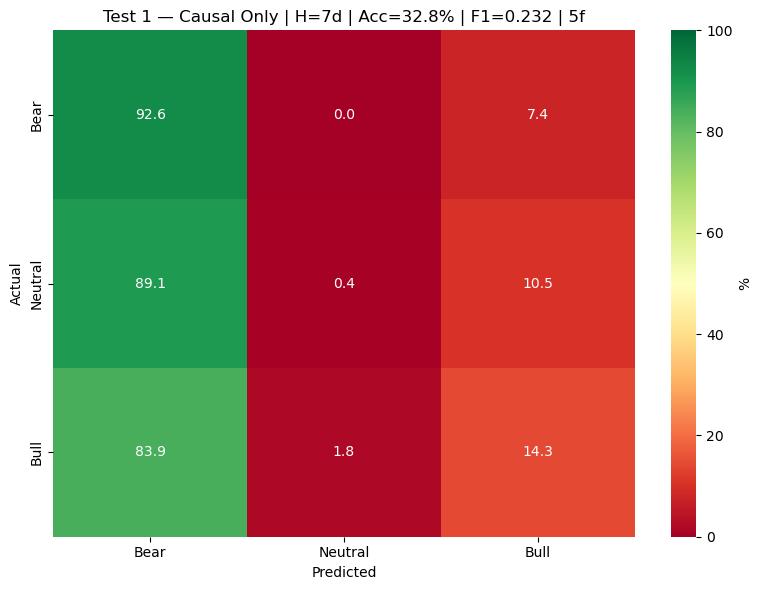

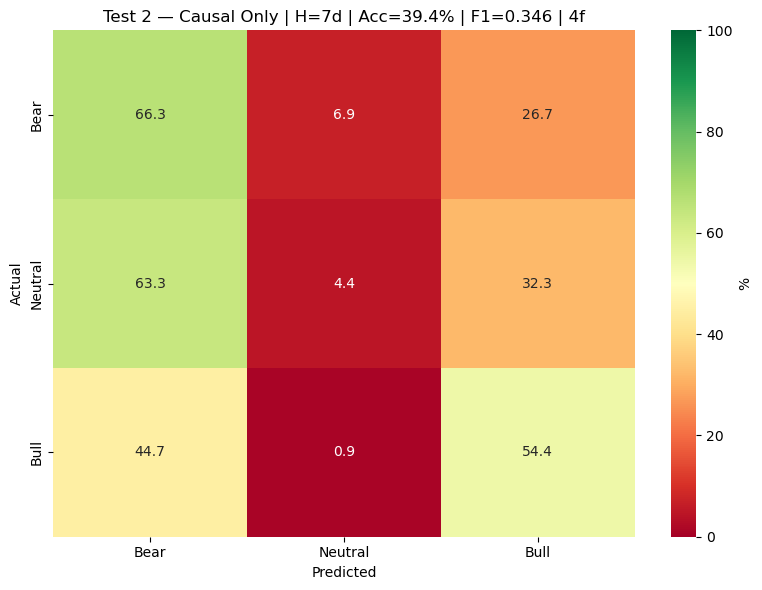

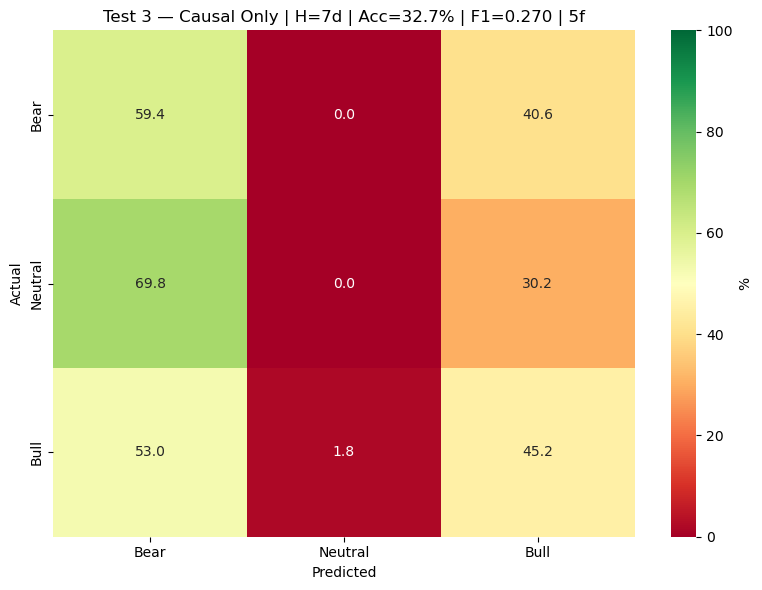

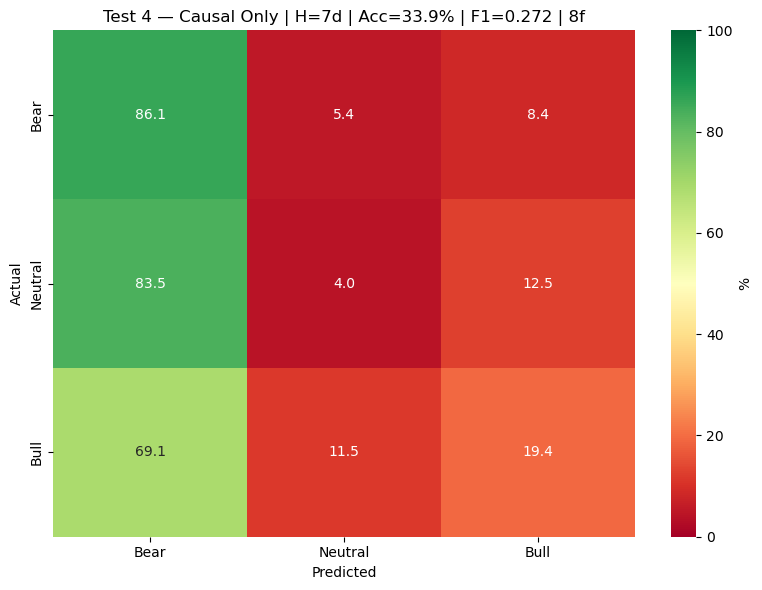

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

SCENARIO_NAMES = ["Bear", "Neutral", "Bull"]

# Show confusion matrices for each test's causal model at horizon 7d
for name, r_list in [("Test 1", results_causal_1), ("Test 2", results_causal_2),
                      ("Test 3", results_causal_3), ("Test 4", results_causal_4)]:
    res = next((r for r in r_list if r["horizon"] == 7), None)
    if res is None: continue

    cm = np.array(res["cm"])
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_pct = cm / row_sums * 100

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="RdYlGn",
                xticklabels=SCENARIO_NAMES, yticklabels=SCENARIO_NAMES,
                vmin=0, vmax=100, cbar_kws={"label": "%"})
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} — Causal Only | H=7d | Acc={res['acc']*100:.1f}% | F1={res['macro_f1']:.3f} | {res['n_features']}f")
    plt.tight_layout()
    plt.show()


### Confusion Matrices Analysis — H=7d (Causal Only)

The confusion matrices reveal how each causal model distributes its predictions across the 3 scenarios (Bear, Neutral, Bull) at the 7-day horizon.

**Test 2 (ML-selected, 4 features)** delivers the most balanced predictions: it correctly identifies 66.3% of Bear periods and 54.4% of Bull periods, with only a minor Neutral detection (6.9%). This is the only model that avoids extreme Bear-bias and manages to distinguish both tails of the return distribution.

**Test 1 and Test 3** suffer from a strong Bear prediction bias — the model classifies 83-92% of all observations as Bear regardless of the actual scenario. This means the model has essentially learned to predict only one class, which inflates accuracy on Bear periods but makes it useless for detecting Bull or Neutral regimes.

**Test 4 (All features, 8 causal vars)** shows the same Bear-bias pattern (69-86% predicted as Bear), confirming that more causal variables does not necessarily mean better discrimination — it can introduce noise that pushes the model toward a single-class default.

**Key takeaway**: Test 2 with only 4 causal features achieves the best balance between detecting Bear AND Bull scenarios. The Neutral class is systematically underdetected across all models (0-7%), which is expected — "neutral" markets are by definition the hardest to distinguish from mild bear or bull conditions. For practical portfolio allocation, the ability to distinguish Bear from Bull (as Test 2 does) is far more valuable than high accuracy on a single class.

## Conclusion

### Methodology
For each set of indicators, we ran:
1. **PC Algorithm** (alpha=0.05, Fisher-Z) to identify causal relationships with BTC
2. **Random Forest** (5 horizons: 1, 7, 14, 30, 60 days) comparing all variables vs causal-only
3. **Final comparison** across all 4 tests to identify the best indicator set

### Tests performed
- **Test 1**: 14 features from RF importance ranking
- **Test 2**: 18 features from ML feature selection
- **Test 3**: 26 features from Alvaro pillars (On-Chain, Macro, Sentiment, Crypto)
- **Test 4**: All ~112 features (after redundancy removal)

### Interactive Graphs
Each test produces an HTML file — click legend to filter, use "BTC links only" button, hover for details.


## Custom test choose your own features

In [109]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# BUILD FEATURE SELECTOR
# ============================================================
available = [c for c in pivot_df.columns if c != "XBTUSD Curncy"]

# Group by category
cat_features = {}
for f in available:
    cat = get_category(f)
    if cat not in cat_features:
        cat_features[cat] = []
    cat_features[cat].append(f)

# Create checkboxes per category in tabs
tabs = {}
checkboxes = {}
for cat in ["On-Chain", "Macro", "Sentiment", "Crypto Market", "Other"]:
    feats = sorted(cat_features.get(cat, []))
    if not feats:
        continue
    cbs = [widgets.Checkbox(value=False, description=f, layout=widgets.Layout(width='300px'))
           for f in feats]
    checkboxes[cat] = cbs
    # Arrange in 3 columns
    rows = []
    for i in range(0, len(cbs), 3):
        rows.append(widgets.HBox(cbs[i:i+3]))
    tabs[cat] = widgets.VBox(rows)

tab_widget = widgets.Tab(children=list(tabs.values()))
for i, cat in enumerate(tabs.keys()):
    tab_widget.set_title(i, f"{cat} ({len(cat_features.get(cat, []))})")

# Select all / deselect all buttons per tab
def select_all(cat):
    for cb in checkboxes.get(cat, []):
        cb.value = True

def deselect_all(cat):
    for cb in checkboxes.get(cat, []):
        cb.value = False

# Counter
selected_label = widgets.HTML(value="<b>Selected: 0 features</b>")

def update_count(*args):
    count = sum(1 for cbs in checkboxes.values() for cb in cbs if cb.value)
    selected_label.value = f"<b>Selected: {count} features</b>"

for cbs in checkboxes.values():
    for cb in cbs:
        cb.observe(update_count, names='value')

# Quick select buttons
btn_select_all = widgets.Button(description="Select All", button_style='info')
btn_deselect_all = widgets.Button(description="Deselect All", button_style='warning')

def on_select_all(b):
    for cat in checkboxes:
        select_all(cat)

def on_deselect_all(b):
    for cat in checkboxes:
        deselect_all(cat)

btn_select_all.on_click(on_select_all)
btn_deselect_all.on_click(on_deselect_all)

# RUN button
btn_run = widgets.Button(description="Run Random Forest", button_style='success',
                         layout=widgets.Layout(width='200px', height='40px'))
output = widgets.Output()

def on_run(b):
    with output:
        clear_output(wait=True)

        # Get selected features
        selected = []
        for cat, cbs in checkboxes.items():
            for cb in cbs:
                if cb.value:
                    selected.append(cb.description)

        if len(selected) < 2:
            print("Please select at least 2 features!")
            return

        print(f"{'='*70}")
        print(f"RUNNING RF WITH {len(selected)} SELECTED FEATURES")
        print(f"{'='*70}")
        for f in selected:
            print(f"  {f:35s} [{get_category(f)}]")

        # RF config
        START_DATE = "2018-03-01"
        TRAIN_END_DATE = "2023-12-31"
        HORIZONS = [1, 7, 14, 30, 60]
        N_BINS = 3
        MIN_ROWS = 300
        SCENARIO_NAMES = ["Bear", "Neutral", "Bull"]
        RF_PARAMS = dict(n_estimators=400, max_depth=12, min_samples_split=10,
                         min_samples_leaf=5, max_features="sqrt",
                         class_weight="balanced", random_state=42, n_jobs=-1)

        def calc_ret(p, h): return (p.shift(-h) - p) / p
        def fit_b(r, n=3):
            qs = np.quantile(r.dropna().values, np.linspace(0, 1, n+1))
            qs[0], qs[-1] = -np.inf, np.inf
            for i in range(1, len(qs)):
                if qs[i] <= qs[i-1]: qs[i] = qs[i-1]+1e-12
            return qs

        results = []
        for h in HORIZONS:
            df = pivot_df.copy()
            df.index = pd.to_datetime(df.index)
            df = df.sort_index()
            df = df[df.index >= pd.to_datetime(START_DATE)]
            btc = "XBTUSD Curncy"
            if btc not in df.columns: continue
            ret = calc_ret(df[btc].astype(float), h)
            feats = [c for c in selected if c in df.columns and c != btc]
            if len(feats) < 2: continue
            dm = df[feats].ffill().copy()
            dm = dm.dropna(axis=1, thresh=int(0.7*len(dm)))
            feats = list(dm.columns)
            dm["t"] = ret
            dm = dm.dropna(subset=["t"])
            cut = pd.to_datetime(TRAIN_END_DATE)
            tr, te = dm[dm.index <= cut], dm[dm.index > cut]
            if len(tr) < MIN_ROWS or len(te) < 50: continue
            bins = fit_b(tr["t"], N_BINS)
            yt = pd.cut(tr["t"], bins=bins, labels=False).dropna().astype(int)
            ye = pd.cut(te["t"], bins=bins, labels=False).dropna().astype(int)
            Xt, Xe = tr[feats].loc[yt.index], te[feats].loc[ye.index]
            sc = StandardScaler()
            Xts, Xes = sc.fit_transform(Xt), sc.transform(Xe)
            clf = RandomForestClassifier(**RF_PARAMS)
            clf.fit(Xts, yt)
            yp = clf.predict(Xes)
            d = DummyClassifier(strategy="most_frequent", random_state=42)
            d.fit(Xts, yt)
            imp = pd.DataFrame({"feature": feats, "importance": clf.feature_importances_})
            imp = imp.sort_values("importance", ascending=False).reset_index(drop=True)

            res = {"horizon": h, "n_features": len(feats),
                   "acc": accuracy_score(ye, yp),
                   "bal_acc": balanced_accuracy_score(ye, yp),
                   "macro_f1": f1_score(ye, yp, average="macro"),
                   "cm": confusion_matrix(ye, yp, labels=list(range(N_BINS))),
                   "dummy_acc": accuracy_score(ye, d.predict(Xes)),
                   "imp": imp}
            results.append(res)
            print(f"\n  H={h:2d}d -> Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | "
                  f"F1={res['macro_f1']:.3f} | Dummy={res['dummy_acc']*100:.1f}%")
            print(f"         Top 5: {', '.join(imp.head(5)['feature'].tolist())}")

        if not results:
            print("No results — check your feature selection.")
            return

        # Summary table
        s = pd.DataFrame([{
            "Horizon": r["horizon"], "Features": r["n_features"],
            "Acc (%)": round(r["acc"]*100, 1), "BalAcc (%)": round(r["bal_acc"]*100, 1),
            "F1": round(r["macro_f1"], 3), "Dummy (%)": round(r["dummy_acc"]*100, 1),
        } for r in results])
        print(f"\n{'='*70}")
        print(s.to_string(index=False))
        print(f"\nAvg BalAcc: {s['BalAcc (%)'].mean():.1f}% | Avg F1: {s['F1'].mean():.3f}")

        # Confusion matrices
        n_plots = len(results)
        fig, axes = plt.subplots(n_plots, 1, figsize=(8, 6*n_plots))
        if n_plots == 1: axes = [axes]
        for idx, res in enumerate(results):
            cm = np.array(res["cm"])
            rs = cm.sum(axis=1, keepdims=True)
            rs[rs == 0] = 1
            cm_pct = cm / rs * 100
            sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="RdYlGn",
                        xticklabels=SCENARIO_NAMES, yticklabels=SCENARIO_NAMES,
                        vmin=0, vmax=100, ax=axes[idx], cbar=idx == n_plots-1)
            axes[idx].set_title(f"H={res['horizon']}d | Acc={res['acc']*100:.0f}%")
            axes[idx].set_xlabel("Predicted")
            if idx == 0: axes[idx].set_ylabel("Actual")
        plt.tight_layout()
        plt.show()

btn_run.on_click(on_run)

# ============================================================
# DISPLAY
# ============================================================
display(widgets.HTML("<h2>Custom Feature Selector</h2>"))
display(widgets.HBox([btn_select_all, btn_deselect_all, selected_label]))
display(tab_widget)
display(btn_run)
display(output)

HTML(value='<h2>Custom Feature Selector</h2>')

Button(button_style='success', description='Run Random Forest', layout=Layout(height='40px', width='200px'), s…

Output()